# ST451 — Bayesian NLP Pipeline for Ancient Greek Philosophical Topic Modelling

**Angelo Saporito | May 2026**

This notebook implements the full analysis pipeline for the ST451 project:
probabilistic preprocessing and topic uncertainty quantification in Ancient
Greek philosophical texts.

**Run order:** cells must be executed top to bottom in a single session.
The lemma cache (`lemma_cache.json`) and pre-scraped corpus (`lemmatized_corpus.json`)
must be present in the working directory to avoid re-scraping (which takes several
hours due to Perseids API rate limiting). If running from scratch, set
`FORCE_RESCRAPE = True` in Section 1.

**Sections:**
1. Corpus scraping and lemmatisation
2. DTM construction and LDA fitting
3. Figures 1–10
4. Extensions (C, A, E, F)

## AI Acknowledgement

In accordance with ST451 Position 2 guidelines on the use of generative AI,
Claude (Anthropic, claude-sonnet-4-5, accessed April–May 2026) was used to
assist with two aspects of this project:

**Coding assistance:** merging three separate analysis notebooks into this
unified pipeline, adding defensive guards (e.g. `FORCE_RESCRAPE` flag, disk
checks before scraping), fixing a variable scoping bug in Extension A6, adding
the `plt.draw()` call required for dendrogram label colouring, and redirecting
all figure output to a `figures/` subdirectory. Representative prompts:
- *"Merge these three Jupyter notebooks into a single unified pipeline with clear section headers and inline comments"*
- *"Add a `FORCE_RESCRAPE` flag so the notebook loads cached artefacts when they exist on disk"*
- *"Fix the variable scoping bug in cell A6 where `gen_top` and `wis_top` are reused across loop iterations"*
- *"Redirect all `plt.savefig` calls to save into a `figures/` subdirectory"*

**Text polishing:** light compression of the accompanying report to meet the
10-page limit. Representative prompts:
- *"This section is four lines over the page limit — compress without removing any findings"*
- *"The limitations section reads as three identically structured paragraphs — rewrite as flowing prose"*

All modelling decisions, hyperparameter choices, results interpretation, and
substantive academic content are the author's own.

---
## Section 1: Corpus Scraping and Lemmatisation

Scrapes the full Plato/Aristotle training corpus and Septuagint projection
texts, runs morphological analysis via the Perseids Morpheus API, and saves
three artefacts to disk:
- `greek_corpus/` — raw JSON files, one per work
- `lemma_cache.json` — persistent cache of surface → lemma posteriors (44,879 forms)
- `lemmatized_corpus.json` — MAP lemmas + weighted counts for all 16 works

**WARNING — Timaeus scrape:** Cell 1.3 overwrites the incomplete Timaeus file
produced by Cell 1.2 (244 tokens, book-level only) with the correct version
(23,790 tokens, explicit Stephanus range 17–92). Both cells must run in order.
Verify `timaeus: 23790 tokens` before proceeding.

In [1]:
# 1.1 imports and configuration

import os
import re
import json
import time
import requests
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import networkx as nx
from bs4 import BeautifulSoup
from pathlib import Path
from collections import defaultdict
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
from sklearn.preprocessing import OneHotEncoder
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

from pipeline        import GreekPipeline
from token_filter    import load_corpus_from_disk, filter_corpus
from lemmatizer      import Lemmatizer
from dtm_builder     import build_dtms
from lda_fitter      import fit_all, print_topics
from greek_stopwords import remove_stopwords
import perseus_scraper as ps

# paths
CORPUS_DIR = 'greek_corpus'
CACHE_PATH = 'lemma_cache.json'
LEMMA_PATH = 'lemmatized_corpus.json'

# set True to force re-scrape even if artefacts exist
FORCE_RESCRAPE = False

# training works — included in DTM and LDA
TRAINING_KEYS = {
    'plato_republic', 'plato_symposium', 'plato_phaedrus',
    'plato_phaedo',   'plato_sophist',   'plato_ion',
    'plato_meno',     'plato_apology',   'plato_timaeus',
    'aristotle_metaphysics', 'aristotle_nicomachean_ethics', 'aristotle_poetics',
}

# held-out works — scraped and lemmatised but not used in LDA training
HELDOUT_KEYS = {
    'septuagint_genesis', 'septuagint_proverbs',
    'septuagint_wisdom',  'septuagint_sirach',
}

os.makedirs(CORPUS_DIR, exist_ok=True)
print('config ok')

[MorphAnalyzer] stanza not installed — using Perseids API only.
  To enable neural parsing: pip install stanza
  Then: python -c "import stanza; stanza.download('grc')"
config ok


In [2]:
# 1.2 scrape Plato and Aristotle (training corpus)
# note: timaeus scrapes only 244 tokens at book level here.
# cell 1.3 corrects this with the explicit stephanus range.

if FORCE_RESCRAPE or not Path('%s/plato_republic.json' % CORPUS_DIR).exists():
    p = GreekPipeline()
    plato_aristotle_spec = [
        {'author': 'plato',     'work': 'republic',           'sections': 'auto'},
        {'author': 'plato',     'work': 'symposium',          'sections': 'auto'},
        {'author': 'plato',     'work': 'phaedrus',           'sections': 'auto'},
        {'author': 'plato',     'work': 'phaedo',             'sections': 'auto'},
        {'author': 'plato',     'work': 'sophist',            'sections': 'auto'},
        {'author': 'plato',     'work': 'ion',                'sections': 'auto'},
        {'author': 'plato',     'work': 'meno',               'sections': 'auto'},
        {'author': 'plato',     'work': 'apology',            'sections': 'auto'},
        {'author': 'aristotle', 'work': 'metaphysics',        'sections': 'auto'},
        {'author': 'aristotle', 'work': 'nicomachean ethics', 'sections': 'auto'},
        {'author': 'aristotle', 'work': 'poetics',            'sections': 'auto'},
    ]
    corpus_pa = p.scrape_corpus(plato_aristotle_spec, output_dir=CORPUS_DIR)
else:
    print('plato/aristotle corpus already on disk — skipping scrape')

plato/aristotle corpus already on disk — skipping scrape


In [3]:
# 1.3 scrape Timaeus with explicit Stephanus range (overwrites cell 1.2 output)
# timaeus is indexed by stephanus page at the top CTS level, not by book number.
# get_all_sections() returns only 1 section (244 tokens); the explicit range
# 17–92 recovers the full text (23,790 tokens).

if FORCE_RESCRAPE or not Path('%s/plato_timaeus.json' % CORPUS_DIR).exists():
    p = GreekPipeline()
    timaeus_sections = [str(n) for n in range(17, 93)]
    corpus_timaeus = p.scrape_corpus(
        [{'author': 'plato', 'work': 'timaeus', 'sections': timaeus_sections}],
        output_dir=CORPUS_DIR,
    )
    n_tok = len(corpus_timaeus.get('plato_timaeus', {}).get('tokens', []))
    print('timaeus: %d tokens' % n_tok)
    assert n_tok > 20000, 'ERROR: timaeus token count too low — check Stephanus range'
else:
    print('timaeus already on disk — skipping scrape')

timaeus already on disk — skipping scrape


In [4]:
# 1.4 scrape Septuagint (held-out, via greekdoc.github.io)
# the Scaife CTS API returns HTTP 500 for all Septuagint URNs (opp-grc1 edition
# not served). greekdoc.github.io hosts an interlinear Greek/English table
# where Greek tokens appear as link text in the left column.

_GREEK_RE = re.compile(r'[\u0370-\u03FF\u1F00-\u1FFF]')

SEP_BOOKS = {
    'genesis':  ('https://greekdoc.github.io/polyglot/genesis{:02d}.html', 50),
    'proverbs': ('https://greekdoc.github.io/polyglot/prov{:02d}.html',    31),
    'wisdom':   ('https://greekdoc.github.io/apocrypha/wis{:02d}.html',    19),
    'sirach':   ('https://greekdoc.github.io/apocrypha/sir{:02d}.html',    51),
}

session = requests.Session()
session.headers.update({
    'User-Agent': 'GreekCorpusScraper/1.0 (academic research)',
    'Accept':     'text/html',
})

def scrape_sep_chapter(url):
    try:
        resp = session.get(url, timeout=15)
        if resp.status_code != 200:
            return []
        soup   = BeautifulSoup(resp.text, 'lxml')
        tokens = []
        for row in soup.find_all('tr'):
            cells = row.find_all('td')
            if not cells:
                continue
            for a in cells[0].find_all('a'):
                w = re.sub(r'[.,·;:\u2014\-\u2013!?\[\]()"\'\u1FBD]+', '',
                           a.get_text().strip()).strip()
                if w and _GREEK_RE.search(w) and len(w) >= 2:
                    tokens.append({'w': w, 'o': 0})
        return tokens
    except Exception:
        return []

if FORCE_RESCRAPE or not Path('%s/septuagint_genesis.json' % CORPUS_DIR).exists():
    corpus_sep = {}
    print('scraping septuagint via greekdoc.github.io')
    for work, (url_pattern, n_chapters) in SEP_BOOKS.items():
        key    = 'septuagint_%s' % work
        tokens = []
        print('  %s (%d chapters)' % (work.title(), n_chapters))
        for ch in range(1, n_chapters + 1):
            tokens.extend(scrape_sep_chapter(url_pattern.format(ch)))
            print('  ch %3d/%d  cumulative: %6d tokens' % (ch, n_chapters, len(tokens)),
                  end='\r')
            time.sleep(0.5)
        doc   = {'author': 'septuagint', 'work': work, 'tokens': tokens}
        fpath = '%s/%s.json' % (CORPUS_DIR, key)
        with open(fpath, 'w', encoding='utf-8') as f:
            json.dump(doc, f, ensure_ascii=False, indent=2)
        corpus_sep[key] = doc
        print('\n  saved -> %s  (%d tokens)' % (fpath, len(tokens)))
    print('septuagint scrape complete')
else:
    print('septuagint corpus already on disk — skipping scrape')

septuagint corpus already on disk — skipping scrape


In [5]:
# 1.5 filter corpus

corpus       = load_corpus_from_disk(CORPUS_DIR)
clean_corpus = filter_corpus(corpus)

print('\ntoken counts after filtering:')
print('%s  %s  %s' % ('work'.ljust(45), 'raw'.rjust(8), 'clean'.rjust(8)))
for key in sorted(clean_corpus):
    doc = clean_corpus[key]
    print('%s  %8d  %8d' % (
        key.ljust(45), doc['token_count_raw'], doc['token_count_clean']))

  Loaded aristotle_metaphysics  (78979 tokens)
  Loaded aristotle_nicomachean_ethics  (56648 tokens)
  Loaded aristotle_poetics  (10269 tokens)
  Loaded plato_apology  (8750 tokens)
  Loaded plato_ion  (4046 tokens)
  Loaded plato_meno  (10283 tokens)
  Loaded plato_phaedo  (22457 tokens)
  Loaded plato_phaedrus  (17029 tokens)
  Loaded plato_republic  (88484 tokens)
  Loaded plato_sophist  (17226 tokens)
  Loaded plato_symposium  (17413 tokens)
  Loaded plato_timaeus  (23790 tokens)
  Loaded septuagint_genesis  (31713 tokens)
  Loaded septuagint_proverbs  (10896 tokens)
  Loaded septuagint_sirach  (18405 tokens)
  Loaded septuagint_wisdom  (6773 tokens)
  aristotle_metaphysics                     78979 →  75613 tokens  (3366 dropped, 4.3%)
  aristotle_nicomachean_ethics              56648 →  54202 tokens  (2446 dropped, 4.3%)
  aristotle_poetics                         10269 →   9691 tokens  (578 dropped, 5.6%)
  plato_apology                              8750 →   8449 tokens  (301 dr

In [6]:
# 1.6 lemmatise
# each unique surface form is looked up in the Perseids Morpheus API.
# results are cached in lemma_cache.json to avoid repeat API calls.
# n_samples=0 here — sampled DTMs are built on-the-fly in section 2.

lm = Lemmatizer(cache_path=CACHE_PATH)

if Path(LEMMA_PATH).exists() and not FORCE_RESCRAPE:
    with open(LEMMA_PATH, encoding='utf-8') as f:
        lemmatized_corpus = json.load(f)
    print('loaded existing lemmatized_corpus.json  (%d works)' % len(lemmatized_corpus))
else:
    lemmatized_corpus = {}
    print('no existing lemmatized corpus — starting fresh')

new_keys = {k for k in clean_corpus if k not in lemmatized_corpus
            and clean_corpus[k]['token_count_clean'] > 0}

if new_keys:
    print('lemmatising %d new works: %s' % (len(new_keys), sorted(new_keys)))
    new_results = lm.lemmatize_corpus(
        {k: clean_corpus[k] for k in new_keys}, n_samples=0)
    for key, doc in new_results.items():
        lemmatized_corpus[key] = {
            'author':             doc['author'],
            'work':               doc['work'],
            'map_lemmas':         doc['map_lemmas'],
            'weighted_counts':    doc['weighted_counts'],
            'n_tokens':           doc['n_tokens'],
            'n_unique_raw':       doc['n_unique_raw'],
            'n_unique_lemmas':    doc['n_unique_lemmas'],
            'mean_lemma_entropy': doc['mean_lemma_entropy'],
            'n_ambiguous':        doc['n_ambiguous'],
        }
else:
    print('all works already lemmatised — nothing to do')

[LemmaCache] Loaded 44879 cached forms from lemma_cache.json
loaded existing lemmatized_corpus.json  (16 works)
all works already lemmatised — nothing to do


In [7]:
# 1.7 save artefacts

with open(LEMMA_PATH, 'w', encoding='utf-8') as f:
    json.dump(lemmatized_corpus, f, ensure_ascii=False, indent=2)
print('saved %s  (%d works)' % (LEMMA_PATH, len(lemmatized_corpus)))

lm.cache.save()
print('saved %s  (%d cached forms)' % (CACHE_PATH, len(lm.cache)))

saved lemmatized_corpus.json  (16 works)
saved lemma_cache.json  (44879 cached forms)


In [8]:
# 1.8 entropy table
# mean lemma entropy per work — primary standalone result reported in section 2.2.
# plato consistently shows higher entropy than aristotle across all works.

DISPLAY_ORDER = [
    'plato_ion',       'plato_meno',       'plato_phaedrus',
    'plato_symposium', 'plato_phaedo',     'plato_apology',
    'plato_sophist',   'plato_republic',   'plato_timaeus',
    'aristotle_poetics', 'aristotle_nicomachean_ethics', 'aristotle_metaphysics',
    'septuagint_proverbs', 'septuagint_wisdom',
    'septuagint_sirach',   'septuagint_genesis',
]

print('%-45s  %8s  %8s  %10s' % ('work', 'tokens', 'entropy', 'ambiguous'))
print('-' * 80)
for key in DISPLAY_ORDER:
    if key not in lemmatized_corpus:
        continue
    doc = lemmatized_corpus[key]
    tag = '(held-out)' if key in HELDOUT_KEYS else '(training)'
    print('%-45s  %8d  %8.3f  %4d/%-5d  %s' % (
        key, doc['n_tokens'], doc['mean_lemma_entropy'],
        doc['n_ambiguous'], doc['n_unique_raw'], tag))

work                                             tokens   entropy   ambiguous
--------------------------------------------------------------------------------
plato_ion                                          3652     0.244   260/1310   (training)
plato_meno                                         9310     0.233   443/2362   (training)
plato_phaedrus                                    16066     0.232   999/5120   (training)
plato_symposium                                   16777     0.206   824/4683   (training)
plato_phaedo                                      21196     0.209   863/4874   (training)
plato_apology                                      8449     0.205   443/2599   (training)
plato_sophist                                     15712     0.200   638/3824   (training)
plato_republic                                    85415     0.194  2550/15063  (training)
plato_timaeus                                     23316     0.208  1147/6403   (training)
aristotle_poetics              

---
## Section 2: DTM Construction and LDA Fitting

Builds three document-term matrices encoding distinct epistemic stances toward
morphological uncertainty, then fits LDA under all three at K=15.

- **Baseline DTM:** MAP lemma per token (standard approach)
- **Weighted DTM:** posterior-expected fractional counts
- **Sampled DTM:** 50 Monte Carlo realisations from the morphological posterior

Key output: `phi_std` — the empirical standard deviation of topic-word
distributions across the 50 sampled fits. This is the primary uncertainty
quantification measure reported in Section 4.2 of the paper.

In [9]:
# 2.1 configuration

K          = 15
N_ITER     = 100
CHUNK_SIZE = 300
MIN_DF     = 5
MAX_DF     = 0.9
N_SAMPLES  = 50
SEED       = 42

# display constants
WORK_ORDER = [
    'plato_apology', 'plato_meno', 'plato_ion',
    'plato_republic', 'plato_symposium', 'plato_phaedrus',
    'plato_phaedo', 'plato_sophist', 'plato_timaeus',
    'aristotle_nicomachean_ethics', 'aristotle_metaphysics', 'aristotle_poetics',
]

WORK_LABELS = {
    'plato_apology':                  'Apology',
    'plato_meno':                     'Meno',
    'plato_ion':                      'Ion',
    'plato_republic':                 'Republic',
    'plato_symposium':                'Symposium',
    'plato_phaedrus':                 'Phaedrus',
    'plato_phaedo':                   'Phaedo',
    'plato_sophist':                  'Sophist',
    'plato_timaeus':                  'Timaeus',
    'aristotle_nicomachean_ethics':   'NE',
    'aristotle_metaphysics':          'Metaphysics',
    'aristotle_poetics':              'Poetics',
}

PERIOD_COLORS = {
    'plato_apology':                '#2196F3',  # early plato — blue
    'plato_meno':                   '#2196F3',
    'plato_ion':                    '#2196F3',
    'plato_republic':               '#9C27B0',  # middle plato — purple
    'plato_symposium':              '#9C27B0',
    'plato_phaedrus':               '#9C27B0',
    'plato_phaedo':                 '#9C27B0',
    'plato_sophist':                '#673AB7',  # late plato — deep purple
    'plato_timaeus':                '#673AB7',
    'aristotle_nicomachean_ethics': '#F44336',  # aristotle — red
    'aristotle_metaphysics':        '#F44336',
    'aristotle_poetics':            '#F44336',
}

# topic labels derived from top-word inspection of the final run
# t0:  ἀδικέω, τραγῳδία, μῦθος, μίμησις, λέξις, κωμῳδία
# t1:  ὄψις, κύκλος, περίοδος, αἴσθησις, φάος        — timaeus vision/cosmology
# t2:  ἰδέα, φρόνησις, εἶδος, παράδειγμα, νοέω
# t3:  γένος, εἶδος, διαφορά, ζώιον, διαιρέω          — aristotelian division
# t4:  σωκρατέω, ψεῦδος, ψευδής, ψεύδω                — dialectic/refutation
# t5:  ἡδονά, φίλος, λύπη, χαίρω, εὐδαίμων
# t6:  ἔρως, ἐραστής, ἐρωτικός                        — symposium/phaedrus
# t7:  οὐσία, ἀριθμός, κίνησις, αἰσθητός              — aristotle metaphysics
# t8:  νόμος, φύλαξ, ἦθος, ἁμαρτάνω, τιμάω            — guardians/law/character
# t9:  δικαιοσύνη, ἀδικία, ἕξις, ἀρετάω
# t10: σῶμα, ἀποθνήσκω, ἀθάνατος, θάνατος             — phaedo soul/death
# t11: ἡγέομαι, πείθω, γράφω, νομίζω, διδάσκω         — socratic inquiry
# t12: κάλλος, σφαῖρα, κύκλος, ἀνάλογος, χρῶμα        — timaeus form/beauty
# t13: ἁρμονία, μάθημα, δοξάζω, εἰκών, στάσις
# t14: σῶμα, πῦρ, Γαῖα, ὕδωρ, γένεσις, οὐρανός        — timaeus elements
TOPIC_LABELS = {
     0: 'Mimesis/Poetics',
     1: 'Cosmology/Vision',
     2: 'Forms/Knowledge',
     3: 'Division/Classification',
     4: 'Dialectic/Falsehood',
     5: 'Pleasure/Friendship',
     6: 'Desire/Eros',
     7: 'Metaphysics/Ontology',
     8: 'Law/Character',
     9: 'Justice/Virtue',
    10: 'Soul/Death',
    11: 'Teaching/Inquiry',
    12: 'Form/Beauty',
    13: 'Music/Mathematics',
    14: 'Elements/Cosmogony',
}

print('config ok')

config ok


In [10]:
# 2.2 load lemmatised corpus and restrict to training works

corpus       = load_corpus_from_disk(CORPUS_DIR)
clean_corpus = filter_corpus(corpus)

with open(LEMMA_PATH, encoding='utf-8') as f:
    lemmatized_corpus = json.load(f)

training_lemmatized = {k: v for k, v in lemmatized_corpus.items()
                       if k in TRAINING_KEYS}
training_clean      = {k: v for k, v in clean_corpus.items()
                       if k in TRAINING_KEYS}

print('training works: %d' % len(training_lemmatized))
print('total works in lemmatized corpus: %d' % len(lemmatized_corpus))

  Loaded aristotle_metaphysics  (78979 tokens)
  Loaded aristotle_nicomachean_ethics  (56648 tokens)
  Loaded aristotle_poetics  (10269 tokens)
  Loaded plato_apology  (8750 tokens)
  Loaded plato_ion  (4046 tokens)
  Loaded plato_meno  (10283 tokens)
  Loaded plato_phaedo  (22457 tokens)
  Loaded plato_phaedrus  (17029 tokens)
  Loaded plato_republic  (88484 tokens)
  Loaded plato_sophist  (17226 tokens)
  Loaded plato_symposium  (17413 tokens)
  Loaded plato_timaeus  (23790 tokens)
  Loaded septuagint_genesis  (31713 tokens)
  Loaded septuagint_proverbs  (10896 tokens)
  Loaded septuagint_sirach  (18405 tokens)
  Loaded septuagint_wisdom  (6773 tokens)
  aristotle_metaphysics                     78979 →  75613 tokens  (3366 dropped, 4.3%)
  aristotle_nicomachean_ethics              56648 →  54202 tokens  (2446 dropped, 4.3%)
  aristotle_poetics                         10269 →   9691 tokens  (578 dropped, 5.6%)
  plato_apology                              8750 →   8449 tokens  (301 dr

In [11]:
# 2.3 build three DTMs
# dtm_baseline: MAP lemma per token
# dtm_weighted: posterior-expected fractional counts
# dtm_samples:  50 independent Monte Carlo realisations (shape: 50 x 1133 x 1336)
# all three are saved to disk for reproducibility.
# note: dtm_samples.npy is ~300 MB and is excluded from the git repo (.gitignore).

dtms = build_dtms(
    training_lemmatized,
    training_clean,
    n_samples  = N_SAMPLES,
    chunk_size = CHUNK_SIZE,
    min_df     = MIN_DF,
    max_df     = MAX_DF,
    seed       = SEED,
    cache_path = CACHE_PATH,
)

np.save('dtm_baseline.npy', dtms['dtm_baseline'])
np.save('dtm_weighted.npy', dtms['dtm_weighted'])
np.save('dtm_samples.npy',  dtms['dtm_samples'])

meta = {'vocab': dtms['vocab'], 'doc_keys': dtms['doc_keys'], 'doc_meta': dtms['doc_meta']}
with open('dtm_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('vocabulary: %d lemmas' % len(dtms['vocab']))
print('documents:  %d chunks' % len(dtms['doc_keys']))
print('baseline:   %s' % str(dtms['dtm_baseline'].shape))
print('weighted:   %s' % str(dtms['dtm_weighted'].shape))
print('sampled:    %s' % str(dtms['dtm_samples'].shape))

── Chunking corpus ──
  aristotle_poetics                             → 32 chunks  (~302 lemmas/chunk)
  aristotle_nicomachean_ethics                  → 181 chunks  (~299 lemmas/chunk)
  plato_republic                                → 285 chunks  (~299 lemmas/chunk)
  plato_phaedrus                                → 54 chunks  (~297 lemmas/chunk)
  plato_sophist                                 → 53 chunks  (~296 lemmas/chunk)
  aristotle_metaphysics                         → 252 chunks  (~300 lemmas/chunk)
  plato_apology                                 → 28 chunks  (~301 lemmas/chunk)
  plato_ion                                     → 12 chunks  (~304 lemmas/chunk)
  plato_symposium                               → 56 chunks  (~299 lemmas/chunk)
  plato_timaeus                                 → 78 chunks  (~298 lemmas/chunk)
  plato_phaedo                                  → 71 chunks  (~298 lemmas/chunk)
  plato_meno                                    → 31 chunks  (~300 lemmas/chunk)

  

In [12]:
# 2.4 fit LDA under all three methods at K=15
# phi_std is the key output: empirical std of topic-word distributions
# across 50 sampled fits. this is the headline uncertainty measure.

results = fit_all(dtms, K=K, n_iter=N_ITER, seed=SEED)

theta    = results['theta_baseline']   # (n_chunks, K)
phi_b    = results['phi_baseline']     # (K, V)
phi_w    = results['phi_weighted']
phi_s    = results['phi_sampled']      # mean phi across samples
phi_std  = results['phi_std']          # std of phi across 50 samples
doc_meta = results['doc_meta']
vocab    = results['vocab']

print_topics(phi_b, vocab, n_words=12, label='baseline K=%d' % K)

ratio = phi_std.mean() / phi_b.std()
print('\nphi_std ratio (sampled/baseline): %.2f%%' % (ratio * 100))

── Fitting baseline LDA  (K=15) ──
  phi:   (15, 1336)   theta: (1133, 15)

── Fitting weighted LDA  (K=15) ──
  phi:   (15, 1336)   theta: (1133, 15)

── Fitting sampled LDA  (K=15, S=50) ──
  Done.  phi_s_all: (50, 15, 1336)

── Summary ──────────────────────────────────────
  Baseline  phi std (mean): 0.0038
  Weighted  phi std (mean): 0.0038
  Sampled   phi std (mean across samples): 0.0014

── Topics (baseline K=15, K=15) ──────────────────────
  Topic  0: ἀδικέω, τραγῳδία, μῦθος, μίμησις, ἀνδρεῖος, λέξις, πρᾶξις, ἑκών, φοβερός, εἴρω, ὑπομένω, κωμῳδία
  Topic  1: ὄψις, ἀπεργάζομαι, γεννάω, ἐντός, κύκλος, τοιόσδε, πρόσθεν, κεφαλή, περίοδος, ἀλήθεια, αἴσθησις, φάος
  Topic  2: ἰδέα, φρόνησις, ἰατρικός, εἶδος, ὑγίεια, ὑγιεινός, γένεσις, νοέω, ἄνω1, οἰκία, παράδειγμα, νέομαι
  Topic  3: γένος, εἶδος, διαφορά, ζώιον, μετέχω, διαιρέω, ἄρσην, τέμνω, θῆλυς, διχάω, διάφορος, ἀφαιρέω
  Topic  4: σωκρατέω, ψεῦδος, κάτος, ψευδής, ἄπειρος1, ἄνοος, ψεύδω, οὐδʼ, ἐπαινέω, δισσός, κάθημαι, περαίνω

In [13]:
# 2.5 helper functions

def work_key(m):
    return '%s_%s' % (m['author'], m['work'].replace(' ', '_'))

def work_theta_means(theta, doc_meta):
    """aggregate chunk-level theta to work-level means."""
    wt = {}
    for d, m in enumerate(doc_meta):
        k = work_key(m)
        wt.setdefault(k, []).append(theta[d])
    return {k: np.mean(v, axis=0) for k, v in wt.items()}

def js_divergence(p, q):
    """jensen-shannon divergence between two distributions."""
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log(a[mask] / b[mask]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def build_dist_matrix(ordered, work_means):
    n = len(ordered)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = js_divergence(work_means[ordered[i]], work_means[ordered[j]])
    return D

legend_patches = [
    mpatches.Patch(color='#2196F3', label='Early Plato'),
    mpatches.Patch(color='#9C27B0', label='Middle Plato'),
    mpatches.Patch(color='#673AB7', label='Late Plato'),
    mpatches.Patch(color='#F44336', label='Aristotle'),
]

work_means = work_theta_means(theta, doc_meta)
ordered    = [w for w in WORK_ORDER if w in work_means]
mat        = np.array([work_means[w] for w in ordered])
ylabels    = [WORK_LABELS[w] for w in ordered]
colors     = [PERIOD_COLORS[w] for w in ordered]

print('helper functions ready')

# create figures output directory
import os as _os
FIGURES_DIR = 'figures'
_os.makedirs(FIGURES_DIR, exist_ok=True)
print('figures will be saved to: %s/' % FIGURES_DIR)

helper functions ready
figures will be saved to: figures/


---
## Section 3: Figures 1–10

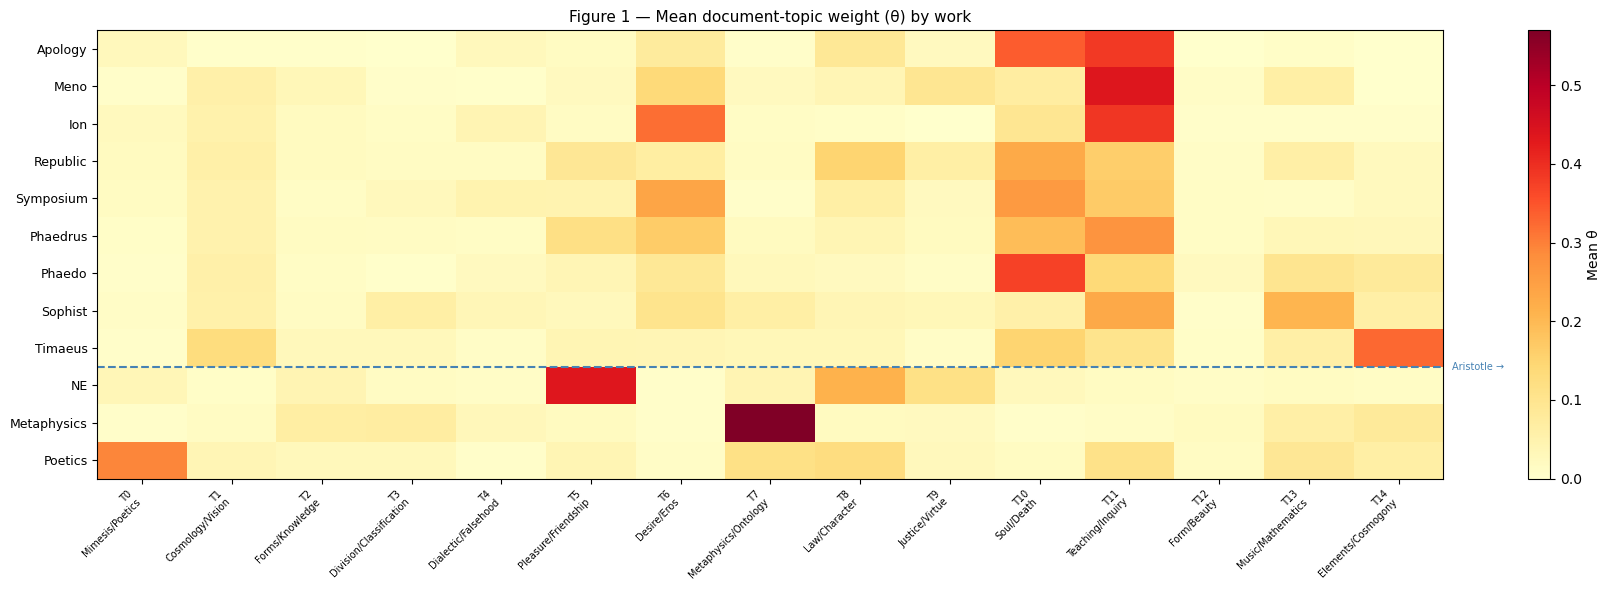

saved fig1


In [14]:
# figure 1 — mean document-topic weight (theta) by work

xlabels = ['T%d\n%s' % (k, TOPIC_LABELS[k]) for k in range(K)]

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(K))
ax.set_xticklabels(xlabels, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_title('Figure 1 — Mean document-topic weight (\u03b8) by work', fontsize=11)
plt.colorbar(im, ax=ax, label='Mean \u03b8')

n_plato = sum(1 for w in ordered if 'plato' in w)
ax.axhline(n_plato - 0.5, color='steelblue', linewidth=1.5, linestyle='--')
ax.text(K - 0.4, n_plato - 0.5, 'Aristotle \u2192',
        fontsize=7, color='steelblue', va='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig1_theta_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig1_theta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig1')

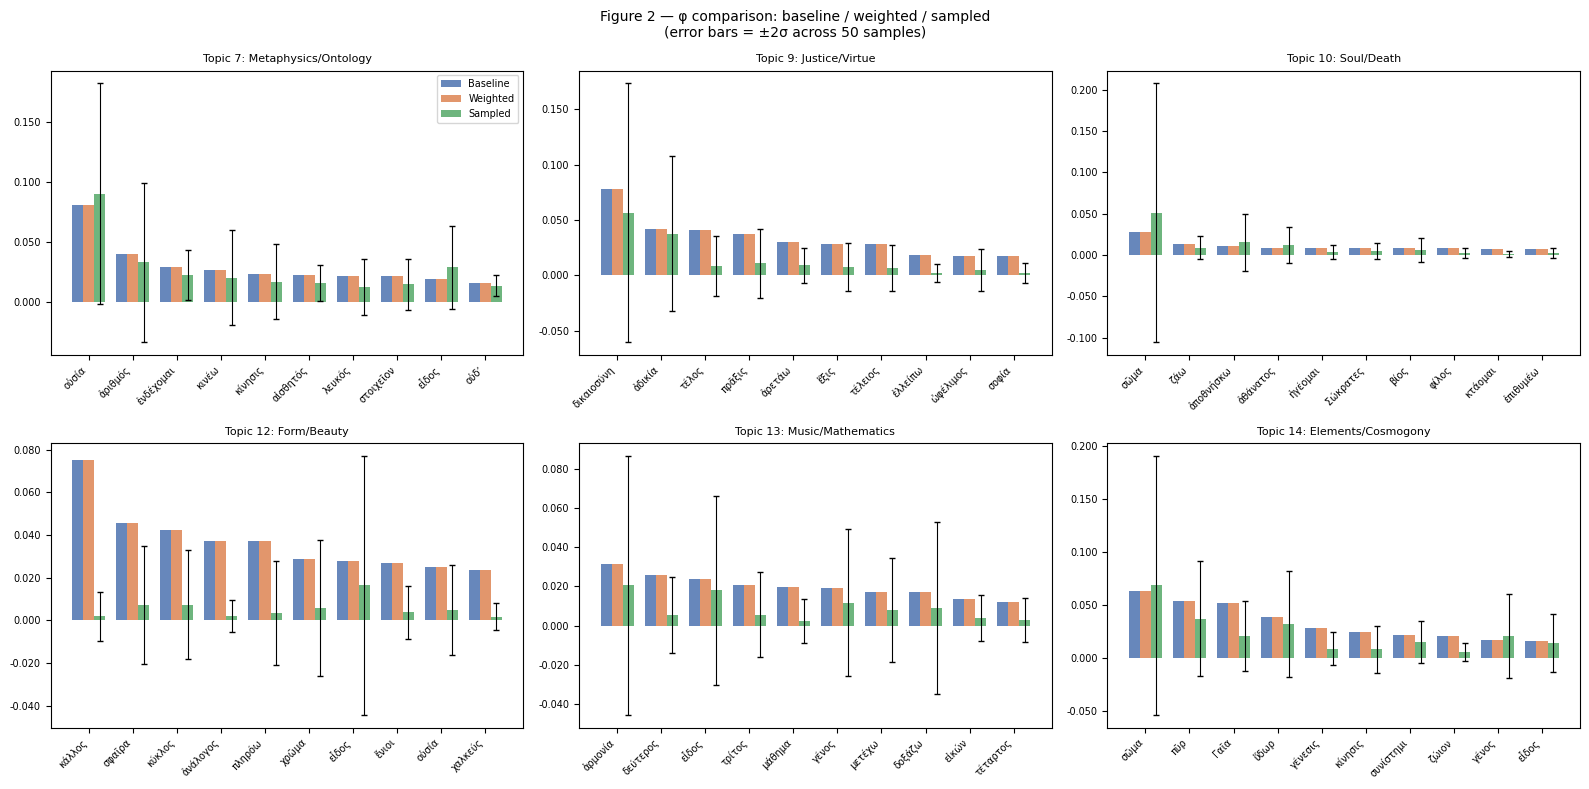

saved fig2


In [15]:
# figure 2 — phi comparison: baseline / weighted / sampled

FOCUS_TOPICS = [7, 9, 10, 12, 13, 14]
n_words      = 10

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, k in zip(axes, FOCUS_TOPICS):
    top_idx  = phi_b[k].argsort()[::-1][:n_words]
    words    = [vocab[i] for i in top_idx]
    b_vals   = phi_b[k, top_idx]
    w_vals   = phi_w[k, top_idx]
    s_vals   = phi_s[k, top_idx]
    std_vals = phi_std[k, top_idx]
    x        = np.arange(n_words)

    ax.bar(x - 0.25, b_vals, 0.25, label='Baseline', color='#4C72B0', alpha=0.85)
    ax.bar(x,        w_vals, 0.25, label='Weighted', color='#DD8452', alpha=0.85)
    ax.bar(x + 0.25, s_vals, 0.25, label='Sampled',  color='#55A868', alpha=0.85)
    ax.errorbar(x + 0.25, s_vals, yerr=2 * std_vals,
                fmt='none', color='black', capsize=2, linewidth=0.8)
    ax.set_title('Topic %d: %s' % (k, TOPIC_LABELS[k]), fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.tick_params(axis='y', labelsize=7)
    if k == FOCUS_TOPICS[0]:
        ax.legend(fontsize=7)

fig.suptitle('Figure 2 \u2014 \u03c6 comparison: baseline / weighted / sampled\n'
             '(error bars = \u00b12\u03c3 across 50 samples)', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig2_phi_comparison.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig2_phi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig2')

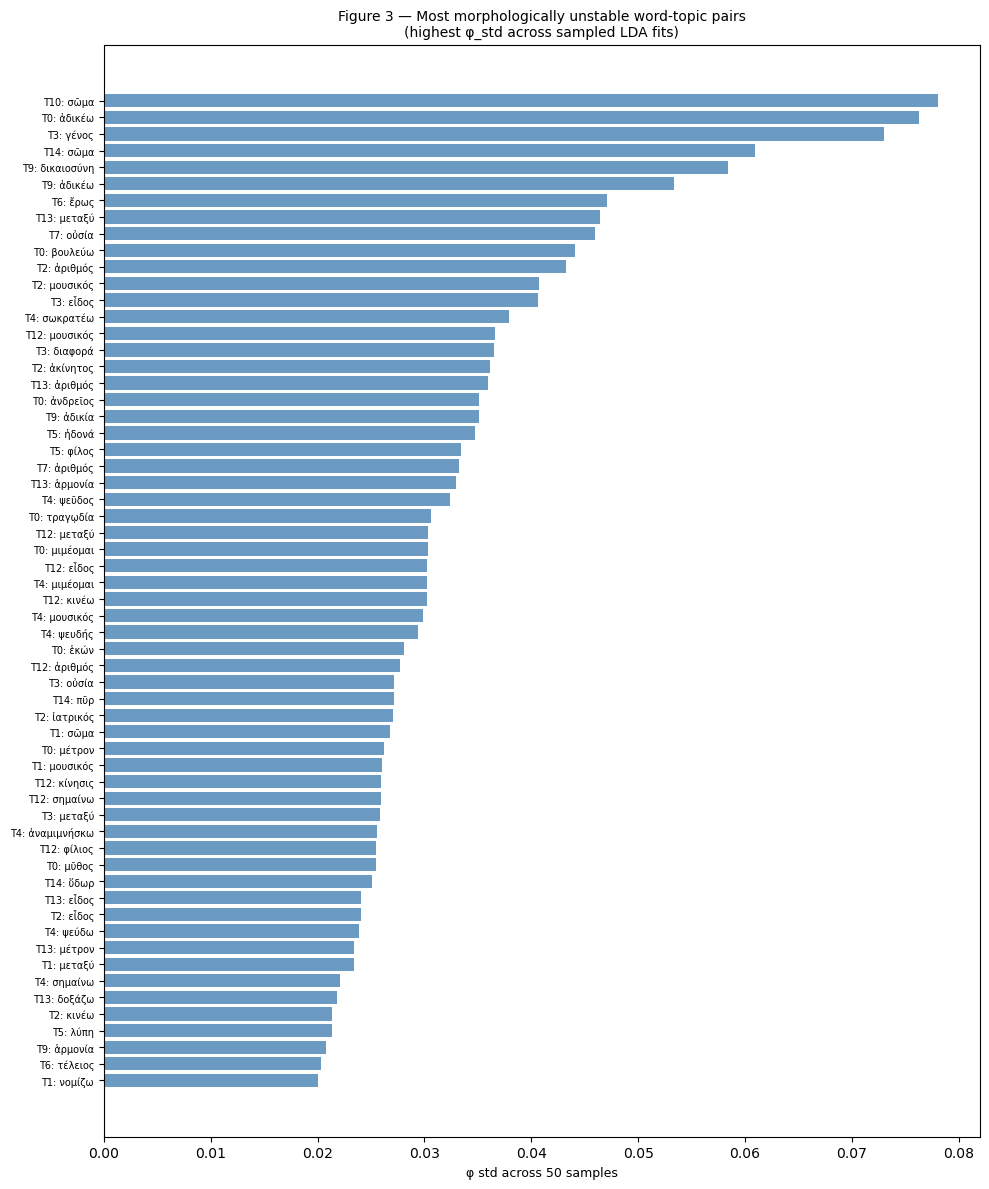


phi std summary by topic
topic   label                           mean phi_std  max phi_std
0       Mimesis/Poetics                   0.001762    0.076291
1       Cosmology/Vision                  0.001874    0.026779
2       Forms/Knowledge                   0.001608    0.043253
3       Division/Classification           0.001265    0.072963
4       Dialectic/Falsehood               0.001805    0.037897
5       Pleasure/Friendship               0.000949    0.034765
6       Desire/Eros                       0.001422    0.047062
7       Metaphysics/Ontology              0.000691    0.045991
8       Law/Character                     0.000982    0.013629
9       Justice/Virtue                    0.001501    0.058428
10      Soul/Death                        0.001239    0.078088
11      Teaching/Inquiry                  0.000799    0.010622
12      Form/Beauty                       0.002207    0.036569
13      Music/Mathematics                 0.001706    0.046445
14      Elements/Cosmogony

In [16]:
# figure 3 — most morphologically unstable word-topic pairs

n_top  = 8
labels = []
stds   = []
for k in range(K):
    top_idx = phi_std[k].argsort()[::-1][:n_top]
    for i in top_idx:
        labels.append('T%d: %s' % (k, vocab[i]))
        stds.append(phi_std[k, i])

order  = np.argsort(stds)[::-1][:60]
labels = [labels[i] for i in order]
stds   = [stds[i]   for i in order]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(range(len(stds)), stds, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('\u03c6 std across 50 samples', fontsize=9)
ax.set_title('Figure 3 — Most morphologically unstable word-topic pairs\n'
             '(highest \u03c6_std across sampled LDA fits)', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig3_phi_std.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig3_phi_std.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nphi std summary by topic')
print('%-6s  %-30s  %10s  %10s' % ('topic', 'label', 'mean phi_std', 'max phi_std'))
for k in range(K):
    print('%-6d  %-30s  %10.6f  %10.6f' % (
        k, TOPIC_LABELS[k], phi_std[k].mean(), phi_std[k].max()))
print('\nbaseline phi std (mean): %.4f' % phi_b.std())
print('sampled  phi std (mean): %.4f' % phi_std.mean())
print('ratio sampled/baseline:  %.2f%%' % (phi_std.mean() / phi_b.std() * 100))
print('saved fig3')

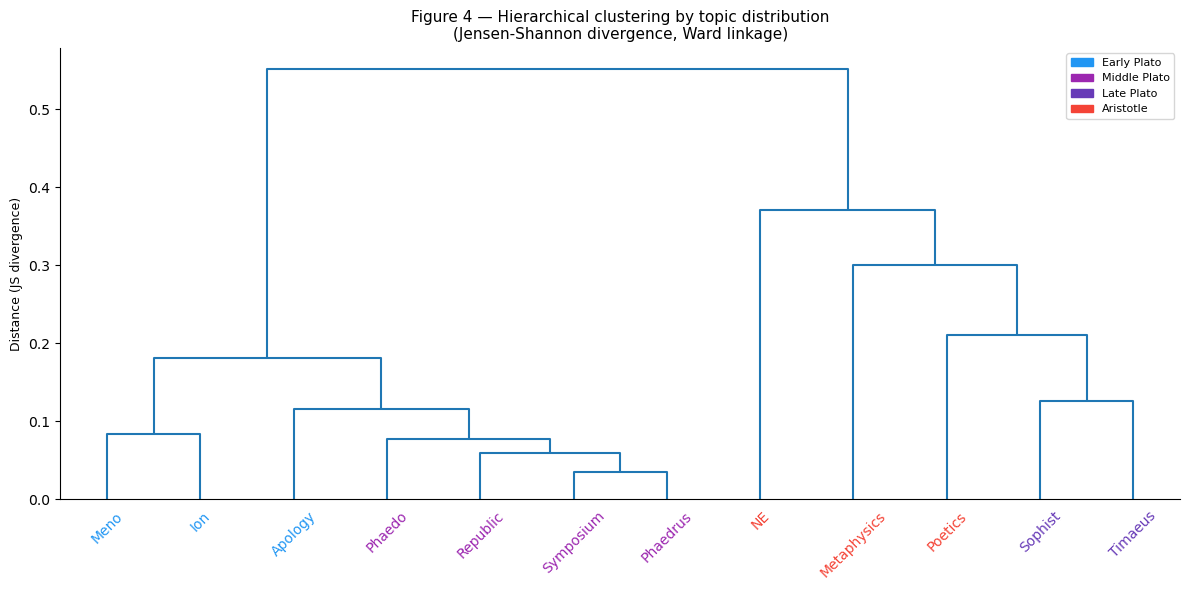

saved fig4


In [17]:
# figure 4 — hierarchical clustering (jensen-shannon divergence)
# plt.draw() must be called before iterating ax.get_xticklabels()
# to ensure leaf labels are populated before colour assignment.

dist_mat  = build_dist_matrix(ordered, work_means)
condensed = dist_mat[np.triu_indices(len(ordered), k=1)]
Z         = linkage(condensed, method='ward')

label_to_key = {v: k for k, v in WORK_LABELS.items()}

fig, ax = plt.subplots(figsize=(12, 6))
ddata = dendrogram(Z, labels=ylabels, ax=ax,
                   leaf_rotation=45, leaf_font_size=10, color_threshold=0)
plt.draw()  # required: populate xticklabels before iterating

for lbl in ax.get_xticklabels():
    text = lbl.get_text()
    wk   = label_to_key.get(text)
    if wk and wk in PERIOD_COLORS:
        lbl.set_color(PERIOD_COLORS[wk])

legend_patches_dend = [
    mpatches.Patch(color='#2196F3', label='Early Plato'),
    mpatches.Patch(color='#9C27B0', label='Middle Plato'),
    mpatches.Patch(color='#673AB7', label='Late Plato'),
    mpatches.Patch(color='#F44336', label='Aristotle'),
]

ax.set_title('Figure 4 \u2014 Hierarchical clustering by topic distribution\n'
             '(Jensen-Shannon divergence, Ward linkage)', fontsize=11)
ax.set_ylabel('Distance (JS divergence)', fontsize=9)
ax.legend(handles=legend_patches_dend, fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig4_dendrogram.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig4_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig4')

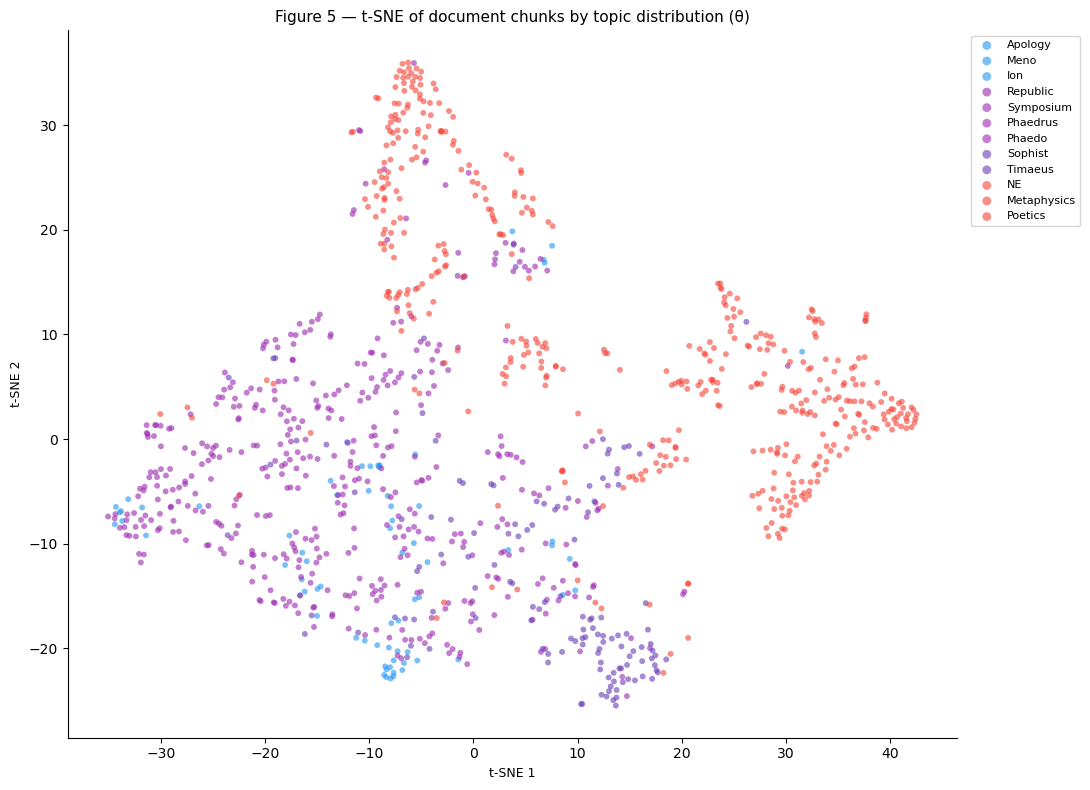

saved fig5


In [18]:
# figure 5 — t-SNE of document chunks by topic distribution

tsne   = TSNE(n_components=2, perplexity=40, random_state=SEED,
              learning_rate='auto', init='pca')
coords = tsne.fit_transform(theta)

fig, ax = plt.subplots(figsize=(11, 8))
for w in ordered:
    idx = [i for i, m in enumerate(doc_meta) if work_key(m) == w]
    ax.scatter(coords[idx, 0], coords[idx, 1],
               c=PERIOD_COLORS[w], s=18, alpha=0.6,
               label=WORK_LABELS[w], edgecolors='none')

ax.legend(fontsize=8, markerscale=1.5, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Figure 5 — t-SNE of document chunks by topic distribution (\u03b8)', fontsize=11)
ax.set_xlabel('t-SNE 1', fontsize=9)
ax.set_ylabel('t-SNE 2', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig5_tsne.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig5_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig5')

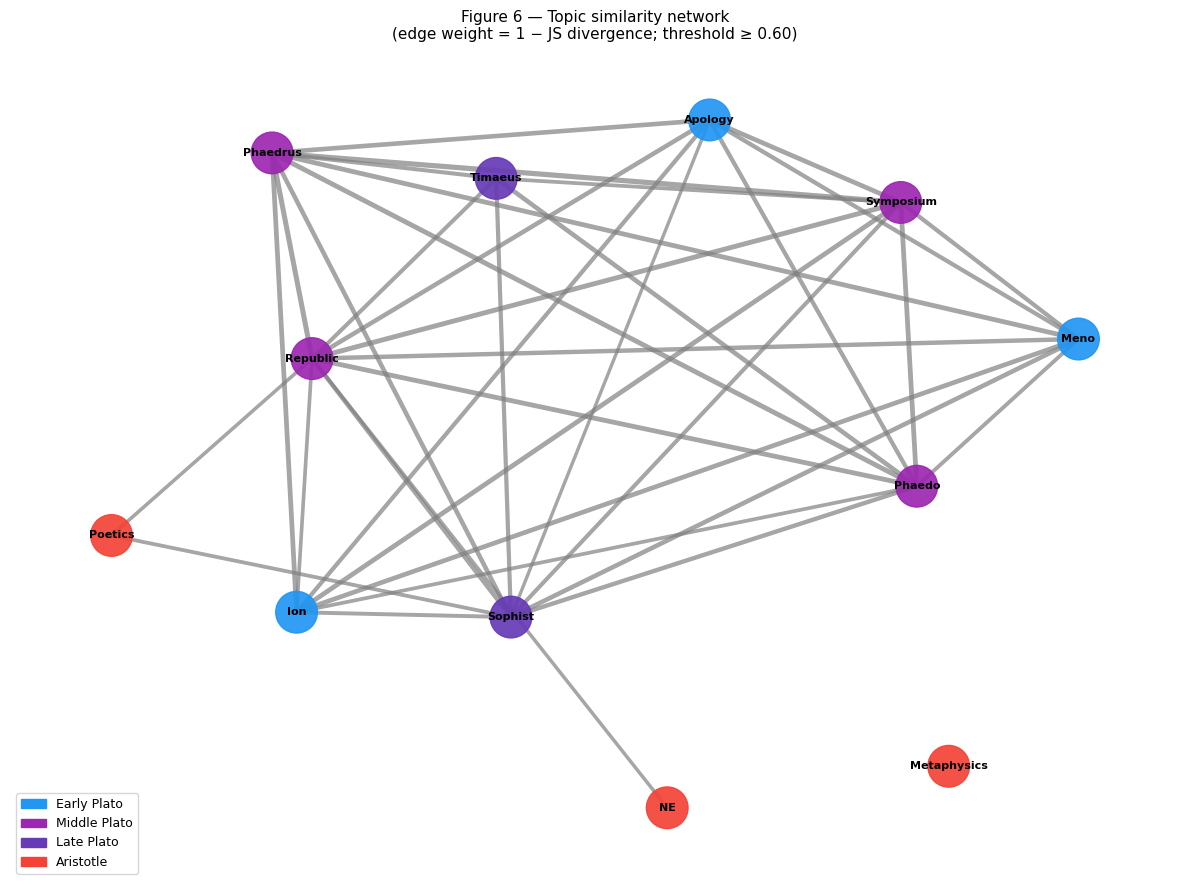

saved fig6


In [19]:
# figure 6 — topic similarity network

EDGE_THRESHOLD = 0.60
sim_mat = 1 - dist_mat / dist_mat.max()
G       = nx.Graph()
for i, w in enumerate(ordered):
    G.add_node(w, label=WORK_LABELS[w], color=PERIOD_COLORS[w])
for i in range(len(ordered)):
    for j in range(i + 1, len(ordered)):
        if sim_mat[i, j] >= EDGE_THRESHOLD:
            G.add_edge(ordered[i], ordered[j], weight=sim_mat[i, j])

pos      = nx.spring_layout(G, weight='weight', seed=SEED, k=2.5)
n_colors = [PERIOD_COLORS[w] for w in G.nodes()]
edges    = list(G.edges(data=True))
e_widths = [d['weight'] * 4 for _, _, d in edges]

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=900, alpha=0.92, ax=ax)
nx.draw_networkx_labels(G, pos, labels={w: WORK_LABELS[w] for w in G.nodes()},
                        font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=e_widths, alpha=0.7, edge_color='grey', ax=ax)
ax.set_title('Figure 6 — Topic similarity network\n'
             '(edge weight = 1 \u2212 JS divergence; threshold \u2265 %.2f)' % EDGE_THRESHOLD,
             fontsize=11)
ax.legend(handles=legend_patches, fontsize=9, loc='lower left')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig6_network.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig6_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig6')

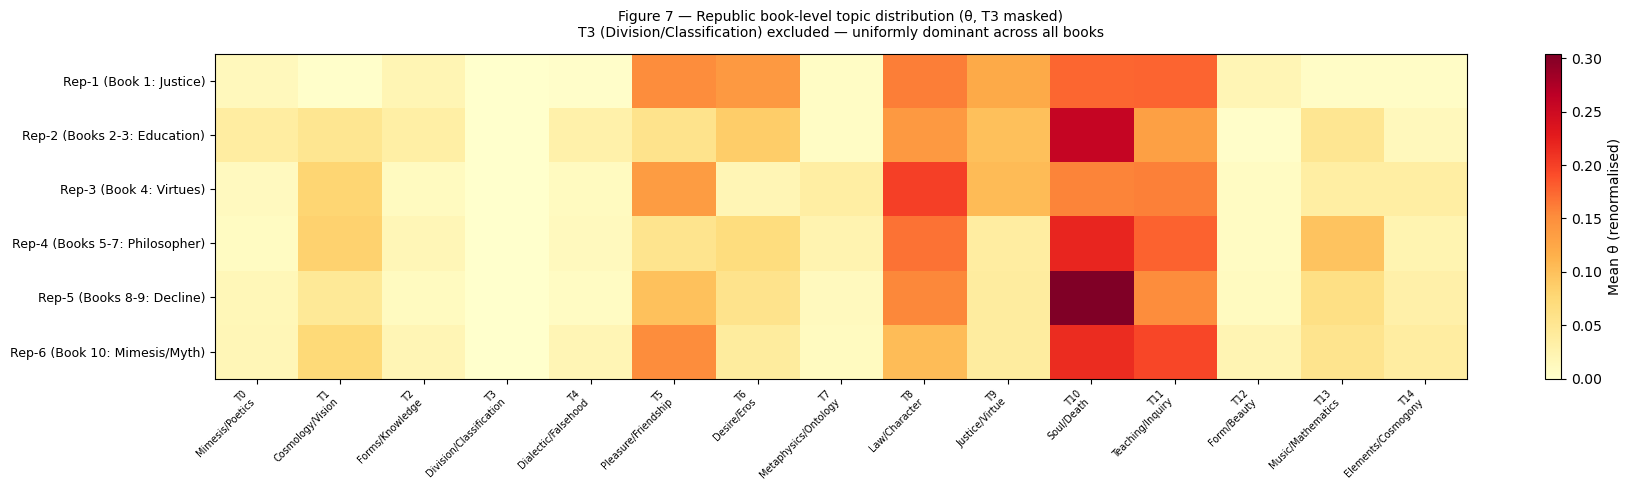

saved fig7


In [20]:
# figure 7 — republic book-level theta heatmap
# t3 (division/classification) excluded: uniform background signal across all books.
# excluding it reveals genuine within-republic topical variation.

BOOK_BOUNDS = {
    'Rep-1 (Book 1: Justice)':        (0,   26),
    'Rep-2 (Books 2-3: Education)':   (26,  87),
    'Rep-3 (Book 4: Virtues)':        (87,  111),
    'Rep-4 (Books 5-7: Philosopher)': (111, 198),
    'Rep-5 (Books 8-9: Decline)':     (198, 245),
    'Rep-6 (Book 10: Mimesis/Myth)':  (245, 285),
}

BOOK_COLORS = {
    'Rep-1 (Book 1: Justice)':        '#B39DDB',
    'Rep-2 (Books 2-3: Education)':   '#9575CD',
    'Rep-3 (Book 4: Virtues)':        '#7E57C2',
    'Rep-4 (Books 5-7: Philosopher)': '#673AB7',
    'Rep-5 (Books 8-9: Decline)':     '#512DA8',
    'Rep-6 (Book 10: Mimesis/Myth)':  '#311B92',
}

def get_book_label(chunk_idx):
    for label, (lo, hi) in BOOK_BOUNDS.items():
        if lo <= chunk_idx < hi:
            return label
    return 'Rep-?'

rep_chunks  = [(d, m) for d, m in enumerate(doc_meta) if work_key(m) == 'plato_republic']
book_thetas = {k: [] for k in BOOK_BOUNDS}
for rank, (d, m) in enumerate(rep_chunks):
    book_thetas[get_book_label(rank)].append(theta[d])

book_means = {k: np.mean(v, axis=0) for k, v in book_thetas.items() if v}

EXCLUDE_TOPICS = [3]

def masked_theta(vec, exclude):
    m = vec.copy()
    m[exclude] = 0.0
    total = m.sum()
    return m / total if total > 0 else m

book_means_masked = {k: masked_theta(v, EXCLUDE_TOPICS) for k, v in book_means.items()}

bmat     = np.array([book_means_masked[k] for k in BOOK_BOUNDS if k in book_means_masked])
bylabels = [k for k in BOOK_BOUNDS if k in book_means_masked]

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(bmat, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(K))
ax.set_xticklabels(xlabels, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(bylabels)))
ax.set_yticklabels(bylabels, fontsize=9)
ax.set_title('Figure 7 — Republic book-level topic distribution (\u03b8, T3 masked)\n'
             'T3 (Division/Classification) excluded — uniformly dominant across all books',
             fontsize=10, pad=12)
plt.colorbar(im, ax=ax, label='Mean \u03b8 (renormalised)')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig7_republic_books.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig7_republic_books.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig7')

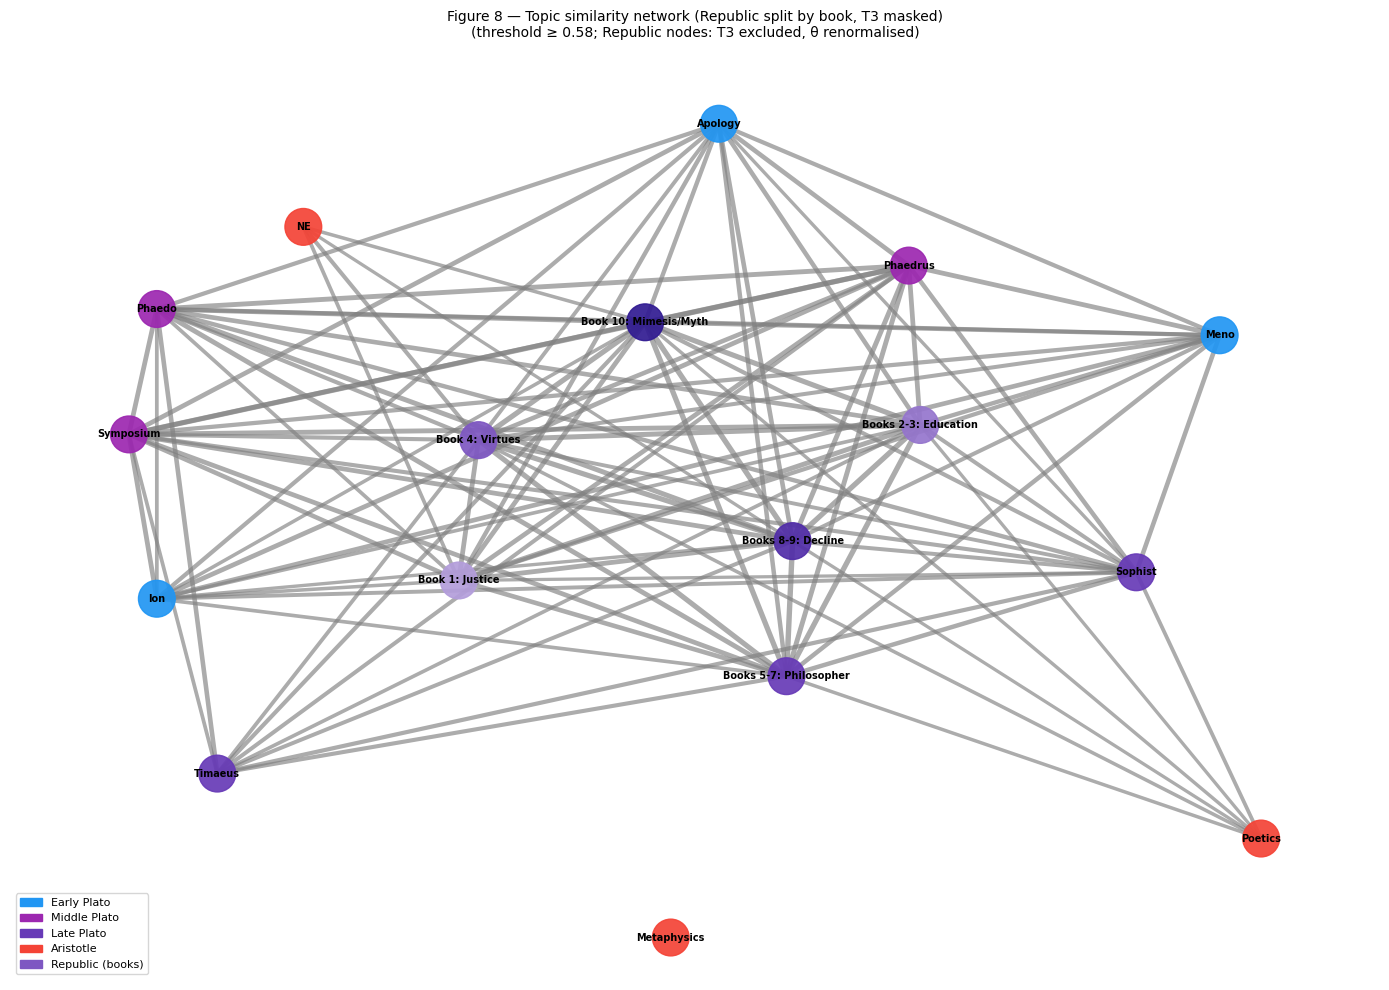

saved fig8


In [21]:
# figure 8 — topic similarity network with republic split by book

WORK_ORDER_NO_REP = [w for w in WORK_ORDER if w != 'plato_republic']
other_means = {w: work_means[w] for w in WORK_ORDER_NO_REP if w in work_means}

all_nodes = {}
for w in WORK_ORDER_NO_REP:
    if w in other_means:
        all_nodes[w] = {'label': WORK_LABELS[w], 'color': PERIOD_COLORS[w],
                        'theta': other_means[w]}
for k in BOOK_BOUNDS:
    if k in book_means_masked:
        short = k.split('(')[1].rstrip(')')
        all_nodes[k] = {'label': short, 'color': BOOK_COLORS[k],
                        'theta': book_means_masked[k]}

node_ids = list(all_nodes.keys())
n        = len(node_ids)
D8       = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D8[i, j] = js_divergence(all_nodes[node_ids[i]]['theta'],
                                  all_nodes[node_ids[j]]['theta'])
sim8    = 1 - D8 / D8.max()
THRESH8 = 0.58

G8 = nx.Graph()
for nid, props in all_nodes.items():
    G8.add_node(nid, label=props['label'], color=props['color'])
for i in range(n):
    for j in range(i + 1, n):
        if sim8[i, j] >= THRESH8:
            G8.add_edge(node_ids[i], node_ids[j], weight=sim8[i, j])

pos8      = nx.spring_layout(G8, weight='weight', seed=SEED, k=2.2)
n8_colors = [all_nodes[nd]['color'] for nd in G8.nodes()]
edges8    = list(G8.edges(data=True))
e8_widths = [d['weight'] * 4 for _, _, d in edges8]

book_patches = legend_patches + [
    mpatches.Patch(color='#7E57C2', label='Republic (books)'),
]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G8, pos8, node_color=n8_colors, node_size=700, alpha=0.92, ax=ax)
nx.draw_networkx_labels(G8, pos8,
                        labels={nd: all_nodes[nd]['label'] for nd in G8.nodes()},
                        font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G8, pos8, width=e8_widths, alpha=0.65, edge_color='grey', ax=ax)
ax.legend(handles=book_patches, fontsize=8, loc='lower left')
ax.set_title('Figure 8 — Topic similarity network (Republic split by book, T3 masked)\n'
             '(threshold \u2265 %.2f; Republic nodes: T3 excluded, \u03b8 renormalised)' % THRESH8,
             fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig8_network_republic_books.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig8_network_republic_books.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig8')

lda model fitted  perplexity: 746.4
  projected septuagint_genesis                   -> 106 chunks
  projected septuagint_proverbs                  -> 36 chunks
  projected septuagint_sirach                    -> 62 chunks
  projected septuagint_wisdom                    -> 23 chunks


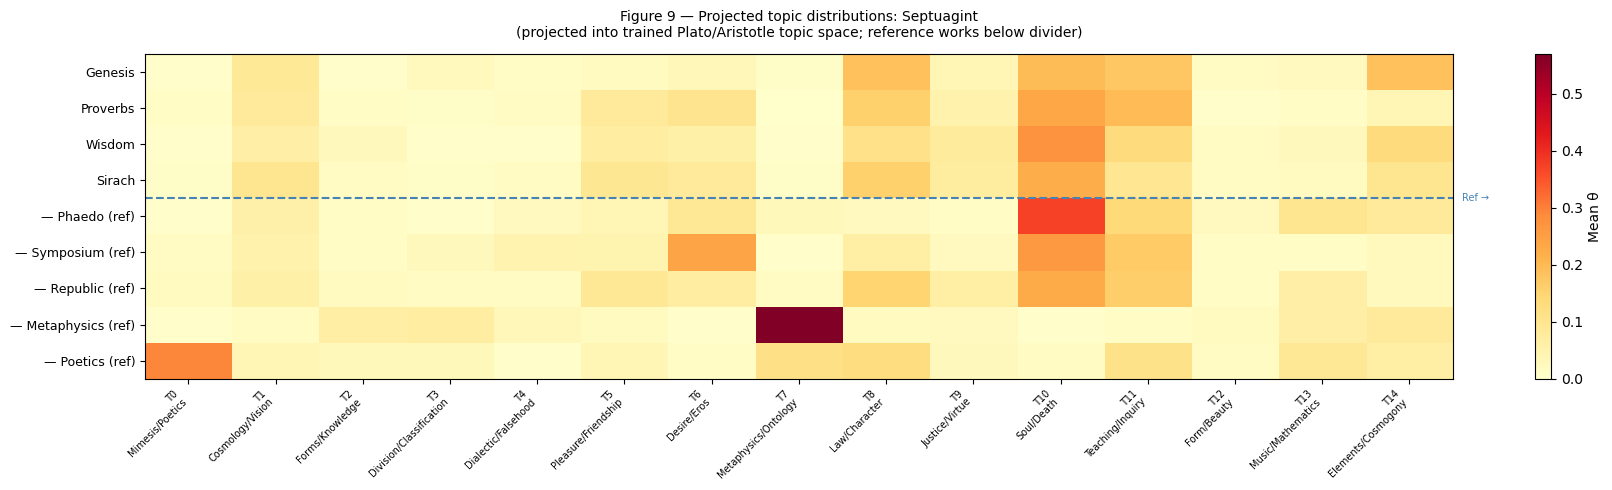

saved fig9


In [22]:
# figure 9 — septuagint projection heatmap
# refit lda on baseline DTM to get transform() method for held-out projection.
# perplexity should reproduce at 746.4.

lda_model = LatentDirichletAllocation(
    n_components    = K,
    max_iter        = N_ITER,
    learning_method = 'online',
    batch_size      = 128,
    learning_offset = 10.0,
    learning_decay  = 0.7,
    random_state    = SEED,
    n_jobs          = 1,
)
lda_model.fit(dtms['dtm_baseline'])
print('lda model fitted  perplexity: %.1f' % lda_model.perplexity(dtms['dtm_baseline']))

vocab_index = dtms['vocab_index']
V           = len(vocab_index)

def project_lemmas(lemmas):
    """convert a lemma list to a DTM row aligned to the training vocabulary."""
    row = np.zeros(V, dtype=np.float32)
    for l in remove_stopwords(lemmas):
        if l in vocab_index:
            row[vocab_index[l]] += 1
    return row

projected = {}
for key in sorted(HELDOUT_KEYS):
    if key not in lemmatized_corpus:
        continue
    lemmas  = lemmatized_corpus[key]['map_lemmas']
    chunks  = [lemmas[i:i + CHUNK_SIZE] for i in range(0, len(lemmas), CHUNK_SIZE)]
    if len(chunks) > 1 and len(chunks[-1]) < 100:
        chunks = chunks[:-1]
    if not chunks:
        continue
    dtm_new   = np.array([project_lemmas(c) for c in chunks])
    theta_new = lda_model.transform(dtm_new)
    projected[key] = {
        'mean_theta': theta_new.mean(axis=0),
        'n_chunks':   len(chunks),
    }
    print('  projected %-35s  -> %d chunks' % (key, len(chunks)))

ref_works = {
    'Phaedo':      'plato_phaedo',
    'Symposium':   'plato_symposium',
    'Republic':    'plato_republic',
    'Metaphysics': 'aristotle_metaphysics',
    'Poetics':     'aristotle_poetics',
}
ref_means = {label: work_means[wk] for label, wk in ref_works.items() if wk in work_means}

PROJ_ORDER = [
    'septuagint_genesis', 'septuagint_proverbs',
    'septuagint_wisdom',  'septuagint_sirach',
]
PROJ_LABELS = {
    'septuagint_genesis':  'Genesis',
    'septuagint_proverbs': 'Proverbs',
    'septuagint_wisdom':   'Wisdom',
    'septuagint_sirach':   'Sirach',
}

proj_rows = [(PROJ_LABELS[k], projected[k]['mean_theta'])
             for k in PROJ_ORDER if k in projected]
ref_rows  = [('\u2014 %s (ref)' % lbl, vec) for lbl, vec in ref_means.items()]
all_rows  = proj_rows + ref_rows
pmat      = np.array([r[1] for r in all_rows])

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(pmat, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(K))
ax.set_xticklabels(xlabels, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(all_rows)))
ax.set_yticklabels([r[0] for r in all_rows], fontsize=9)
ax.axhline(len(proj_rows) - 0.5, color='steelblue', linewidth=1.5, linestyle='--')
ax.text(K - 0.4, len(proj_rows) - 0.5, 'Ref \u2192',
        fontsize=7, color='steelblue', va='center')
ax.set_title('Figure 9 \u2014 Projected topic distributions: Septuagint\n'
             '(projected into trained Plato/Aristotle topic space; reference works below divider)',
             fontsize=10, pad=12)
plt.colorbar(im, ax=ax, label='Mean \u03b8')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig9_projection_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig9_projection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig9')

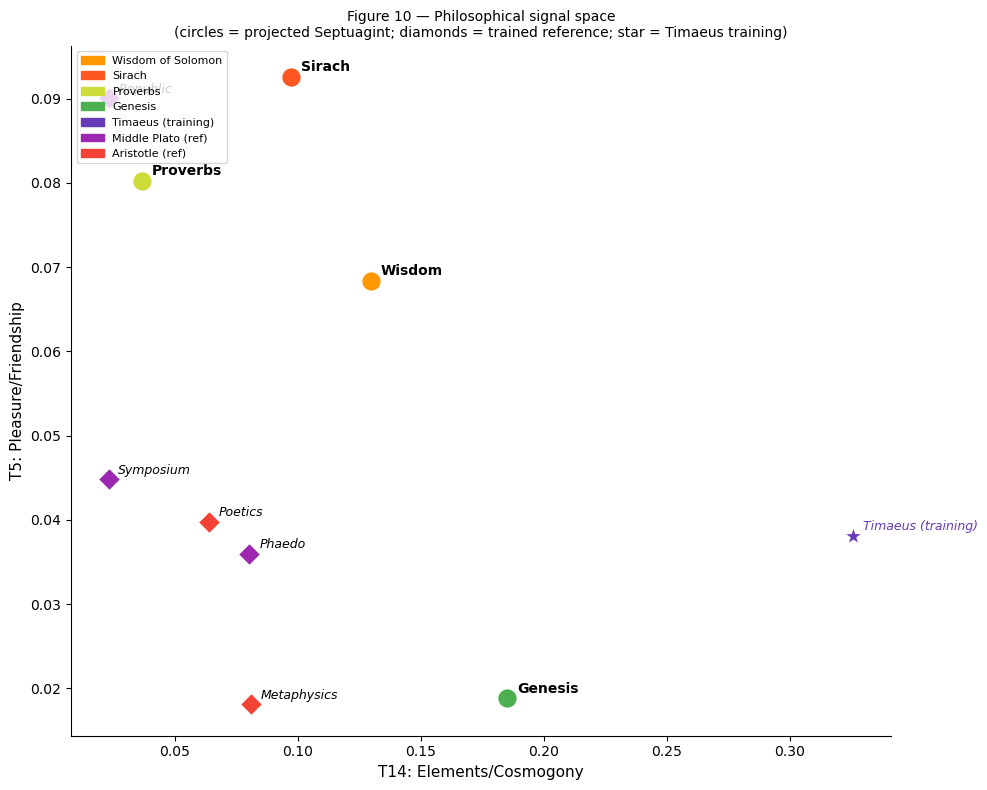

saved fig10


In [23]:
# figure 10 — philosophical signal space scatter

PHIL_T1 = 14   # elements/cosmogony
PHIL_T2 =  5   # pleasure/friendship

PROJ_COLORS = {
    'septuagint_genesis':  '#4CAF50',
    'septuagint_proverbs': '#CDDC39',
    'septuagint_wisdom':   '#FF9800',
    'septuagint_sirach':   '#FF5722',
}
REF_COLORS = {
    'Phaedo':      '#9C27B0',
    'Symposium':   '#9C27B0',
    'Republic':    '#9C27B0',
    'Metaphysics': '#F44336',
    'Poetics':     '#F44336',
}

timaeus_ref = work_means.get('plato_timaeus')

fig, ax = plt.subplots(figsize=(10, 8))

for k in PROJ_ORDER:
    if k not in projected:
        continue
    mt = projected[k]['mean_theta']
    ax.scatter(mt[PHIL_T1], mt[PHIL_T2], s=200,
               color=PROJ_COLORS[k], zorder=3, edgecolors='white', linewidth=1)
    ax.annotate(PROJ_LABELS[k], (mt[PHIL_T1], mt[PHIL_T2]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=10, fontweight='bold')

for lbl, vec in ref_means.items():
    ax.scatter(vec[PHIL_T1], vec[PHIL_T2], s=130,
               color=REF_COLORS[lbl], zorder=3, marker='D',
               edgecolors='white', linewidth=1)
    ax.annotate(lbl, (vec[PHIL_T1], vec[PHIL_T2]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, style='italic')

if timaeus_ref is not None:
    ax.scatter(timaeus_ref[PHIL_T1], timaeus_ref[PHIL_T2], s=200,
               color='#673AB7', zorder=3, marker='*',
               edgecolors='white', linewidth=1)
    ax.annotate('Timaeus (training)', (timaeus_ref[PHIL_T1], timaeus_ref[PHIL_T2]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, style='italic', color='#673AB7')

ax.set_xlabel('T%d: %s' % (PHIL_T1, TOPIC_LABELS[PHIL_T1]), fontsize=11)
ax.set_ylabel('T%d: %s' % (PHIL_T2, TOPIC_LABELS[PHIL_T2]), fontsize=11)
ax.set_title('Figure 10 \u2014 Philosophical signal space\n'
             '(circles = projected Septuagint; diamonds = trained reference; '
             'star = Timaeus training)', fontsize=10)

fig10_patches = [
    mpatches.Patch(color='#FF9800', label='Wisdom of Solomon'),
    mpatches.Patch(color='#FF5722', label='Sirach'),
    mpatches.Patch(color='#CDDC39', label='Proverbs'),
    mpatches.Patch(color='#4CAF50', label='Genesis'),
    mpatches.Patch(color='#673AB7', label='Timaeus (training)'),
    mpatches.Patch(color='#9C27B0', label='Middle Plato (ref)'),
    mpatches.Patch(color='#F44336', label='Aristotle (ref)'),
]
ax.legend(handles=fig10_patches, fontsize=8, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig10_philscore.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/fig10_philscore.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved fig10')

In [24]:
# summary tables — philosophy scores and top 3 topics per projected work

PHIL_T_SOUL = 10

print('projected theta \u2014 philosophy scores + top 3 topics')
print('%-20s  %6s  %12s  %12s  %12s  top 3 topics' % (
    'work', 'chunks',
    'T%d(Cosm)' % PHIL_T1,
    'T%d(Friend)' % PHIL_T2,
    'T%d(Soul)' % PHIL_T_SOUL,
))
print('-' * 110)

for k in PROJ_ORDER:
    if k not in projected:
        continue
    mt   = projected[k]['mean_theta']
    top3 = mt.argsort()[::-1][:3]
    tstr = ', '.join('T%d:%s(%.3f)' % (t, TOPIC_LABELS[t], mt[t]) for t in top3)
    print('%-20s  %6d  %12.4f  %12.4f  %12.4f  %s' % (
        PROJ_LABELS[k], projected[k]['n_chunks'],
        mt[PHIL_T1], mt[PHIL_T2], mt[PHIL_T_SOUL], tstr))

print()
print('reference works (training corpus means):')
for lbl, vec in ref_means.items():
    print('%-20s  %6s  %12.4f  %12.4f  %12.4f' % (
        lbl, '(ref)', vec[PHIL_T1], vec[PHIL_T2], vec[PHIL_T_SOUL]))

if timaeus_ref is not None:
    print('%-20s  %6s  %12.4f  %12.4f  %12.4f' % (
        'Timaeus (training)', '(ref)',
        timaeus_ref[PHIL_T1], timaeus_ref[PHIL_T2], timaeus_ref[PHIL_T_SOUL]))

projected theta — philosophy scores + top 3 topics
work                  chunks     T14(Cosm)    T5(Friend)     T10(Soul)  top 3 topics
--------------------------------------------------------------------------------------------------------------
Genesis                  106        0.1850        0.0188        0.1949  T10:Soul/Death(0.195), T8:Law/Character(0.187), T14:Elements/Cosmogony(0.185)
Proverbs                  36        0.0368        0.0802        0.2350  T10:Soul/Death(0.235), T11:Teaching/Inquiry(0.196), T8:Law/Character(0.157)
Wisdom                    23        0.1296        0.0684        0.2726  T10:Soul/Death(0.273), T11:Teaching/Inquiry(0.133), T14:Elements/Cosmogony(0.130)
Sirach                    62        0.0972        0.0926        0.2218  T10:Soul/Death(0.222), T8:Law/Character(0.156), T1:Cosmology/Vision(0.099)

reference works (training corpus means):
Phaedo                 (ref)        0.0803        0.0360        0.3735
Symposium              (ref)        0.023

---
## Section 4: Extensions

Four extensions to the main analysis:
- **C:** Entropy as register signal — per-chunk morphological entropy within works
- **A:** Septuagint φ-level analysis — cosine-based vocabulary disambiguation
- **E:** Topic coherence under morphological uncertainty — NPMI coherence vs φ_std
- **F:** Post-hoc covariate regression — topic prevalence ~ author + period + genre

### Extension C: Entropy as Register Signal

In [25]:
# C1. per-chunk entropy functions

def chunk_entropy_surface(tokens_clean, chunk_size=300):
    """surface-form entropy: mean H(lemma) over unique forms per chunk."""
    chunks = [tokens_clean[i:i+chunk_size]
              for i in range(0, len(tokens_clean), chunk_size)]
    if len(chunks) > 1 and len(chunks[-1]) < 100:
        chunks = chunks[:-1]
    entropies = []
    for chunk in chunks:
        unique = set(chunk)
        h_vals = []
        for t in unique:
            dist = lm.lemma_dist(t)
            h    = -sum(p * math.log2(p) for p in dist.values() if p > 0)
            h_vals.append(h)
        entropies.append(sum(h_vals) / len(h_vals) if h_vals else 0.0)
    return entropies

def chunk_entropy_token(tokens_clean, chunk_size=300):
    """token-weighted entropy: mean H(lemma) per token position per chunk.
    high-frequency ambiguous forms contribute proportionally to their frequency.
    selected over surface-form entropy based on C3 correlation (r=0.749).
    """
    chunks = [tokens_clean[i:i+chunk_size]
              for i in range(0, len(tokens_clean), chunk_size)]
    if len(chunks) > 1 and len(chunks[-1]) < 100:
        chunks = chunks[:-1]
    entropies = []
    for chunk in chunks:
        h_vals = []
        for t in chunk:
            dist = lm.lemma_dist(t)
            h    = -sum(p * math.log2(p) for p in dist.values() if p > 0)
            h_vals.append(h)
        entropies.append(sum(h_vals) / len(h_vals) if h_vals else 0.0)
    return entropies

def rolling_mean(x, w=5):
    return np.convolve(x, np.ones(w)/w, mode='valid')

print('entropy functions defined')

entropy functions defined


computing republic chunk entropies...
republic chunks: 285


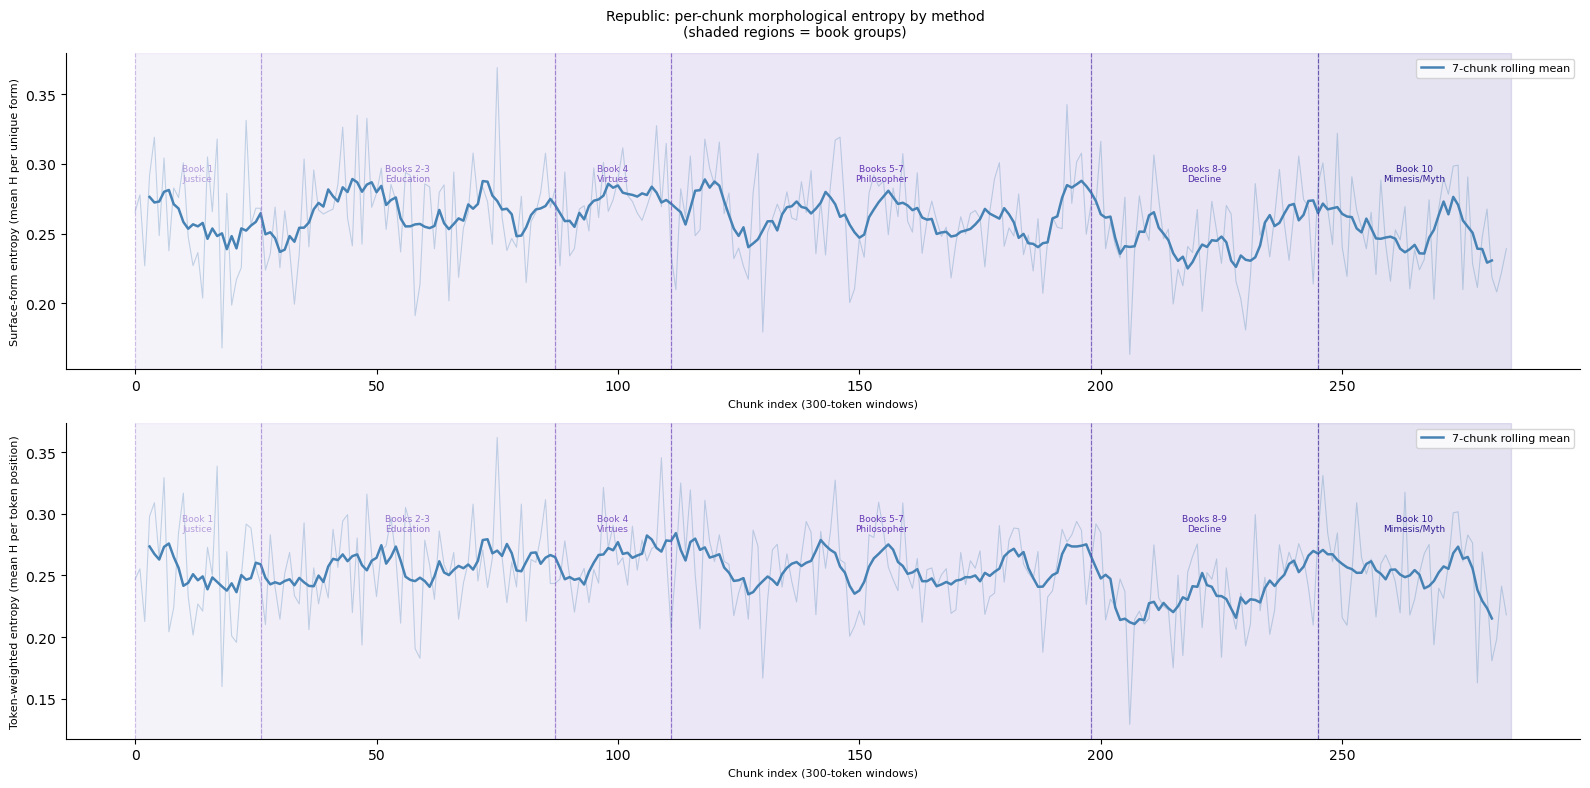

saved ext_c1


In [26]:
# C2. republic: compare both entropy measures across book boundaries

rep_tokens  = clean_corpus['plato_republic']['tokens_clean']
print('computing republic chunk entropies...')
rep_surface = chunk_entropy_surface(rep_tokens, CHUNK_SIZE)
rep_token   = chunk_entropy_token(rep_tokens, CHUNK_SIZE)
n_rep       = len(rep_surface)
chunk_idx   = np.arange(n_rep)
print('republic chunks: %d' % n_rep)

BOOK_BOUNDS_PLOT = {
    'Book 1\nJustice':        (0,   26),
    'Books 2-3\nEducation':   (26,  87),
    'Book 4\nVirtues':        (87,  111),
    'Books 5-7\nPhilosopher': (111, 198),
    'Books 8-9\nDecline':     (198, 245),
    'Book 10\nMimesis/Myth':  (245, 285),
}
BOOK_COLORS_PLOT = ['#B39DDB','#9575CD','#7E57C2','#673AB7','#512DA8','#311B92']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, vals, label in [
    (ax1, rep_surface, 'Surface-form entropy (mean H per unique form)'),
    (ax2, rep_token,   'Token-weighted entropy (mean H per token position)'),
]:
    rm = rolling_mean(vals, w=7)
    ax.plot(chunk_idx, vals, alpha=0.3, color='steelblue', linewidth=0.8)
    ax.plot(np.arange(len(rm)) + 3, rm, color='steelblue', linewidth=1.8,
            label='7-chunk rolling mean')
    for (label_b, (lo, hi)), col in zip(BOOK_BOUNDS_PLOT.items(), BOOK_COLORS_PLOT):
        ax.axvspan(lo, hi, alpha=0.12, color=col)
        ax.axvline(lo, color=col, linewidth=0.8, linestyle='--', alpha=0.6)
        ax.text((lo + hi) / 2, 0.3, label_b,
                ha='center', va='top', fontsize=6.5, color=col)
    ax.set_ylabel(label, fontsize=8)
    ax.set_xlabel('Chunk index (300-token windows)', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

fig.suptitle('Republic: per-chunk morphological entropy by method\n'
             '(shaded regions = book groups)', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/ext_c1_republic_entropy_comparison.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/ext_c1_republic_entropy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved ext_c1')

In [27]:
# C3. republic book-level means (both methods) + method selection

BOOK_BOUNDS_PLAIN = {
    'Book 1: Justice':        (0,   26),
    'Books 2-3: Education':   (26,  87),
    'Book 4: Virtues':        (87,  111),
    'Books 5-7: Philosopher': (111, 198),
    'Books 8-9: Decline':     (198, 245),
    'Book 10: Mimesis/Myth':  (245, 285),
}

print('%-30s  %10s  %10s  |  %10s  %10s' % (
    'book', 'surf_mean', 'surf_std', 'tok_mean', 'tok_std'))
print('-' * 75)

for label, (lo, hi) in BOOK_BOUNDS_PLAIN.items():
    s_vals = rep_surface[lo:hi]
    t_vals = rep_token[lo:hi]
    print('%-30s  %10.4f  %10.4f  |  %10.4f  %10.4f' % (
        label, np.mean(s_vals), np.std(s_vals), np.mean(t_vals), np.std(t_vals)))

r, p = pearsonr(rep_surface, rep_token)
print('\nchunk-level correlation between surface and token entropy:')
print('  r = %.4f  p = %.4e' % (r, p))
# r=0.749 falls in the 0.6-0.85 range: token-weighted preferred for register analysis

book                             surf_mean    surf_std  |    tok_mean     tok_std
---------------------------------------------------------------------------
Book 1: Justice                     0.2607      0.0402  |      0.2539      0.0443
Books 2-3: Education                0.2653      0.0337  |      0.2571      0.0343
Book 4: Virtues                     0.2751      0.0242  |      0.2650      0.0270
Books 5-7: Philosopher              0.2628      0.0296  |      0.2565      0.0311
Books 8-9: Decline                  0.2485      0.0319  |      0.2352      0.0332
Book 10: Mimesis/Myth               0.2522      0.0310  |      0.2522      0.0366

chunk-level correlation between surface and token entropy:
  r = 0.7489  p = 1.6773e-52


computing token-weighted entropy for register works...
  plato_republic: 285 chunks
  plato_phaedo: 71 chunks
  aristotle_metaphysics: 252 chunks
  plato_timaeus: 78 chunks


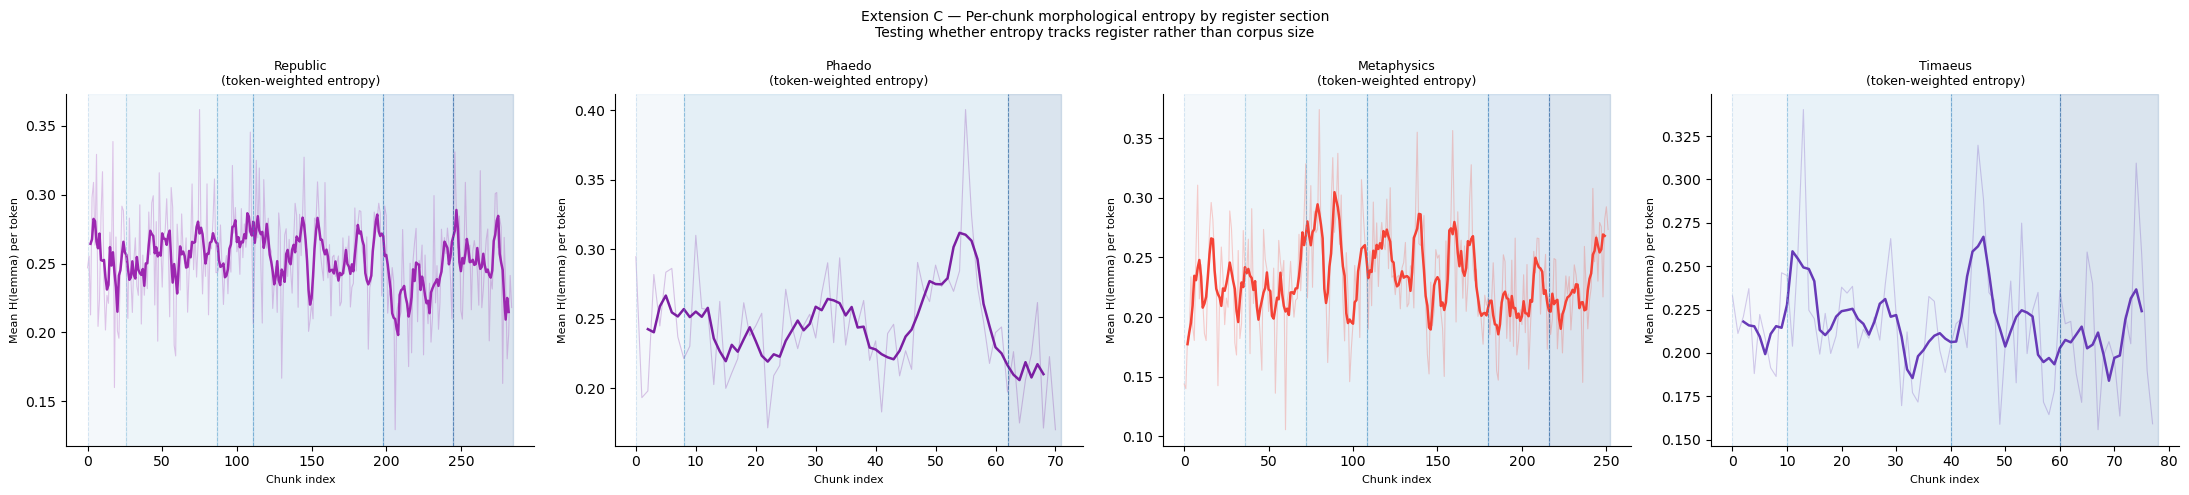

saved ext_c2


In [28]:
# C4. multi-work register analysis and Koentges rebuttal statistic
# token-weighted selected based on C3 correlation result

REGISTER_WORKS = {
    'plato_republic': {
        'label': 'Republic', 'color': '#9C27B0',
        'sections': BOOK_BOUNDS_PLAIN,
    },
    'plato_phaedo': {
        'label': 'Phaedo', 'color': '#7B1FA2',
        'sections': {
            'Biographical frame (57-64)': (0,  8),
            'Arguments (64-107)':         (8,  62),
            'Afterlife myth (107-118)':   (62, 71),
        },
    },
    'aristotle_metaphysics': {
        'label': 'Metaphysics', 'color': '#F44336',
        'sections': {
            'Books 1-2: Historical':  (0,   36),
            'Books 3-4: Aporetic':    (36,  72),
            'Books 5-6: Lexicon/Sci': (72,  108),
            'Books 7-9: Substance':   (108, 180),
            'Books 10-11: Unity/Sci': (180, 216),
            'Books 12-14: Theology':  (216, 252),
        },
    },
    'plato_timaeus': {
        'label': 'Timaeus', 'color': '#673AB7',
        'sections': {
            'Prologue (17-27)':         (0,  10),
            'Cosmology (27-47)':        (10, 40),
            'Second cosmology (47-69)': (40, 60),
            'Physiology (69-92)':       (60, 78),
        },
    },
}

print('computing token-weighted entropy for register works...')
work_chunk_entropies = {}
for key in REGISTER_WORKS:
    tokens = clean_corpus[key]['tokens_clean']
    work_chunk_entropies[key] = chunk_entropy_token(tokens, CHUNK_SIZE)
    print('  %s: %d chunks' % (key, len(work_chunk_entropies[key])))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (key, props) in zip(axes, REGISTER_WORKS.items()):
    vals = work_chunk_entropies[key]
    n    = len(vals)
    rm   = rolling_mean(vals, w=5)
    ax.plot(np.arange(n), vals, alpha=0.25, color=props['color'], linewidth=0.8)
    ax.plot(np.arange(len(rm)) + 2, rm, color=props['color'], linewidth=1.8)
    section_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(props['sections'])))
    for (sec_label, (lo, hi)), col in zip(props['sections'].items(), section_colors):
        if hi <= n:
            ax.axvspan(lo, hi, alpha=0.15, color=col)
            ax.axvline(lo, color=col, linewidth=0.7, linestyle='--', alpha=0.5)
    ax.set_title('%s\n(token-weighted entropy)' % props['label'], fontsize=9)
    ax.set_xlabel('Chunk index', fontsize=8)
    ax.set_ylabel('Mean H(lemma) per token', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Extension C \u2014 Per-chunk morphological entropy by register section\n'
             'Testing whether entropy tracks register rather than corpus size', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/ext_c2_multiwork_register_entropy.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/ext_c2_multiwork_register_entropy.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved ext_c2')

In [29]:
# C5. Koentges rebuttal statistics

print('register entropy summary (token-weighted method)')
print('=' * 70)

for key, props in REGISTER_WORKS.items():
    vals  = work_chunk_entropies[key]
    whole = lemmatized_corpus[key]['mean_lemma_entropy']
    print('\n%s (whole-work entropy = %.4f)' % (props['label'], whole))
    print('%-35s  %10s  %10s  %8s' % ('section', 'mean_H', 'std_H', 'n_chunks'))
    print('-' * 70)
    section_means = []
    for sec_label, (lo, hi) in props['sections'].items():
        if hi <= len(vals):
            sv = vals[lo:hi]
            m, s = np.mean(sv), np.std(sv)
            section_means.append(m)
            print('%-35s  %10.4f  %10.4f  %8d' % (sec_label, m, s, len(sv)))
    if len(section_means) > 1:
        within_range = max(section_means) - min(section_means)
        print('  within-work entropy range: %.4f  (%.1f%% of whole-work mean)' % (
            within_range, within_range / whole * 100))

register entropy summary (token-weighted method)

Republic (whole-work entropy = 0.1940)
section                                  mean_H       std_H  n_chunks
----------------------------------------------------------------------
Book 1: Justice                          0.2539      0.0443        26
Books 2-3: Education                     0.2571      0.0343        61
Book 4: Virtues                          0.2650      0.0270        24
Books 5-7: Philosopher                   0.2565      0.0311        87
Books 8-9: Decline                       0.2352      0.0332        47
Book 10: Mimesis/Myth                    0.2522      0.0366        40
  within-work entropy range: 0.0298  (15.4% of whole-work mean)

Phaedo (whole-work entropy = 0.2090)
section                                  mean_H       std_H  n_chunks
----------------------------------------------------------------------
Biographical frame (57-64)               0.2525      0.0380         8
Arguments (64-107)                   

### Extension A: Septuagint φ-level Analysis

In [30]:
# A1. build vocabulary-aligned DTM rows for Septuagint chunks

vocab_index_ext = {l: i for i, l in enumerate(vocab)}
V_ext = len(vocab_index_ext)

# refit lda for transform() — same hyperparameters as main pipeline
lda_ext = LatentDirichletAllocation(
    n_components=K, max_iter=N_ITER,
    learning_method='online', batch_size=128,
    learning_offset=10.0, learning_decay=0.7,
    random_state=SEED, n_jobs=1,
)
lda_ext.fit(dtms['dtm_baseline'])
print('lda fitted  perplexity: %.1f' % lda_ext.perplexity(dtms['dtm_baseline']))

def project_lemmas_ext(lemmas):
    row = np.zeros(V_ext, dtype=np.float32)
    for l in remove_stopwords(lemmas):
        if l in vocab_index_ext:
            row[vocab_index_ext[l]] += 1
    return row

sep_projected_ext = {}
for key in sorted(HELDOUT_KEYS):
    if key not in lemmatized_corpus:
        continue
    lemmas = lemmatized_corpus[key]['map_lemmas']
    chunks = [lemmas[i:i+CHUNK_SIZE] for i in range(0, len(lemmas), CHUNK_SIZE)]
    if len(chunks) > 1 and len(chunks[-1]) < 100:
        chunks = chunks[:-1]
    if not chunks:
        continue
    dtm_new   = np.array([project_lemmas_ext(c) for c in chunks])
    theta_new = lda_ext.transform(dtm_new)
    sep_projected_ext[key] = {
        'chunks': chunks, 'dtm': dtm_new,
        'theta': theta_new, 'mean_theta': theta_new.mean(axis=0),
        'n_chunks': len(chunks),
    }
    print('projected %-35s  %d chunks' % (key, len(chunks)))

plato_idx   = [i for i, m in enumerate(doc_meta) if 'plato' in m['author']]
plato_theta = theta[plato_idx]
plato_dtm   = dtms['dtm_baseline'][plato_idx]

lda fitted  perplexity: 746.4
projected septuagint_genesis                   106 chunks
projected septuagint_proverbs                  36 chunks
projected septuagint_sirach                    62 chunks
projected septuagint_wisdom                    23 chunks


In [31]:
# A2. cosine similarity: Septuagint vs Plato, per focus topic

N_REF   = 20
N_SEP   = 5
N_WORDS = 20

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

# focus topics chosen for their relevance to wisdom/law literature (T9),
# soul-immortality (T10), mathematical vocabulary (T13), and cosmogony (T14)
FOCUS_TOPICS_A = [9, 10, 13, 14]
SEP_WORKS      = ['septuagint_genesis', 'septuagint_wisdom',
                  'septuagint_sirach',  'septuagint_proverbs']

sim_results = {}
print('cosine similarities: septuagint vs plato on shared topic vocabulary')
print('%-20s  %-35s  %8s  %s' % ('work', 'topic', 'cosine', 'interpretation'))
print('-' * 85)

for key in SEP_WORKS:
    if key not in sep_projected_ext:
        continue
    sep_theta_mat = sep_projected_ext[key]['theta']
    sep_dtm_mat   = sep_projected_ext[key]['dtm']

    for k in FOCUS_TOPICS_A:
        top_word_idx = phi_b[k].argsort()[::-1][:N_WORDS]
        plato_ranks  = plato_theta[:, k].argsort()[::-1][:N_REF]
        plato_mean   = plato_dtm[plato_ranks][:, top_word_idx].mean(axis=0)
        sep_ranks    = sep_theta_mat[:, k].argsort()[::-1][:N_SEP]
        sep_mean     = sep_dtm_mat[sep_ranks][:, top_word_idx].mean(axis=0)

        sim = cosine(plato_mean, sep_mean)
        sim_results[(key, k)] = sim

        if sim > 0.6:
            interp = 'GENUINE \u2014 shared vocabulary'
        elif sim > 0.3:
            interp = 'AMBIGUOUS \u2014 partial overlap'
        else:
            interp = 'FALSE POSITIVE \u2014 different vocab'

        label = key.replace('septuagint_', '').title()
        print('%-20s  T%d: %-30s  %8.4f  %s' % (
            label, k, TOPIC_LABELS[k], sim, interp))

cosine similarities: septuagint vs plato on shared topic vocabulary
work                  topic                                  cosine  interpretation
-------------------------------------------------------------------------------------
Genesis               T9: Justice/Virtue                    0.3596  AMBIGUOUS — partial overlap
Genesis               T10: Soul/Death                        0.4625  AMBIGUOUS — partial overlap
Genesis               T13: Music/Mathematics                 0.2947  FALSE POSITIVE — different vocab
Genesis               T14: Elements/Cosmogony                0.4791  AMBIGUOUS — partial overlap
Wisdom                T9: Justice/Virtue                    0.3915  AMBIGUOUS — partial overlap
Wisdom                T10: Soul/Death                        0.3324  AMBIGUOUS — partial overlap
Wisdom                T13: Music/Mathematics                 0.4945  AMBIGUOUS — partial overlap
Wisdom                T14: Elements/Cosmogony                0.8105  GENUINE — s

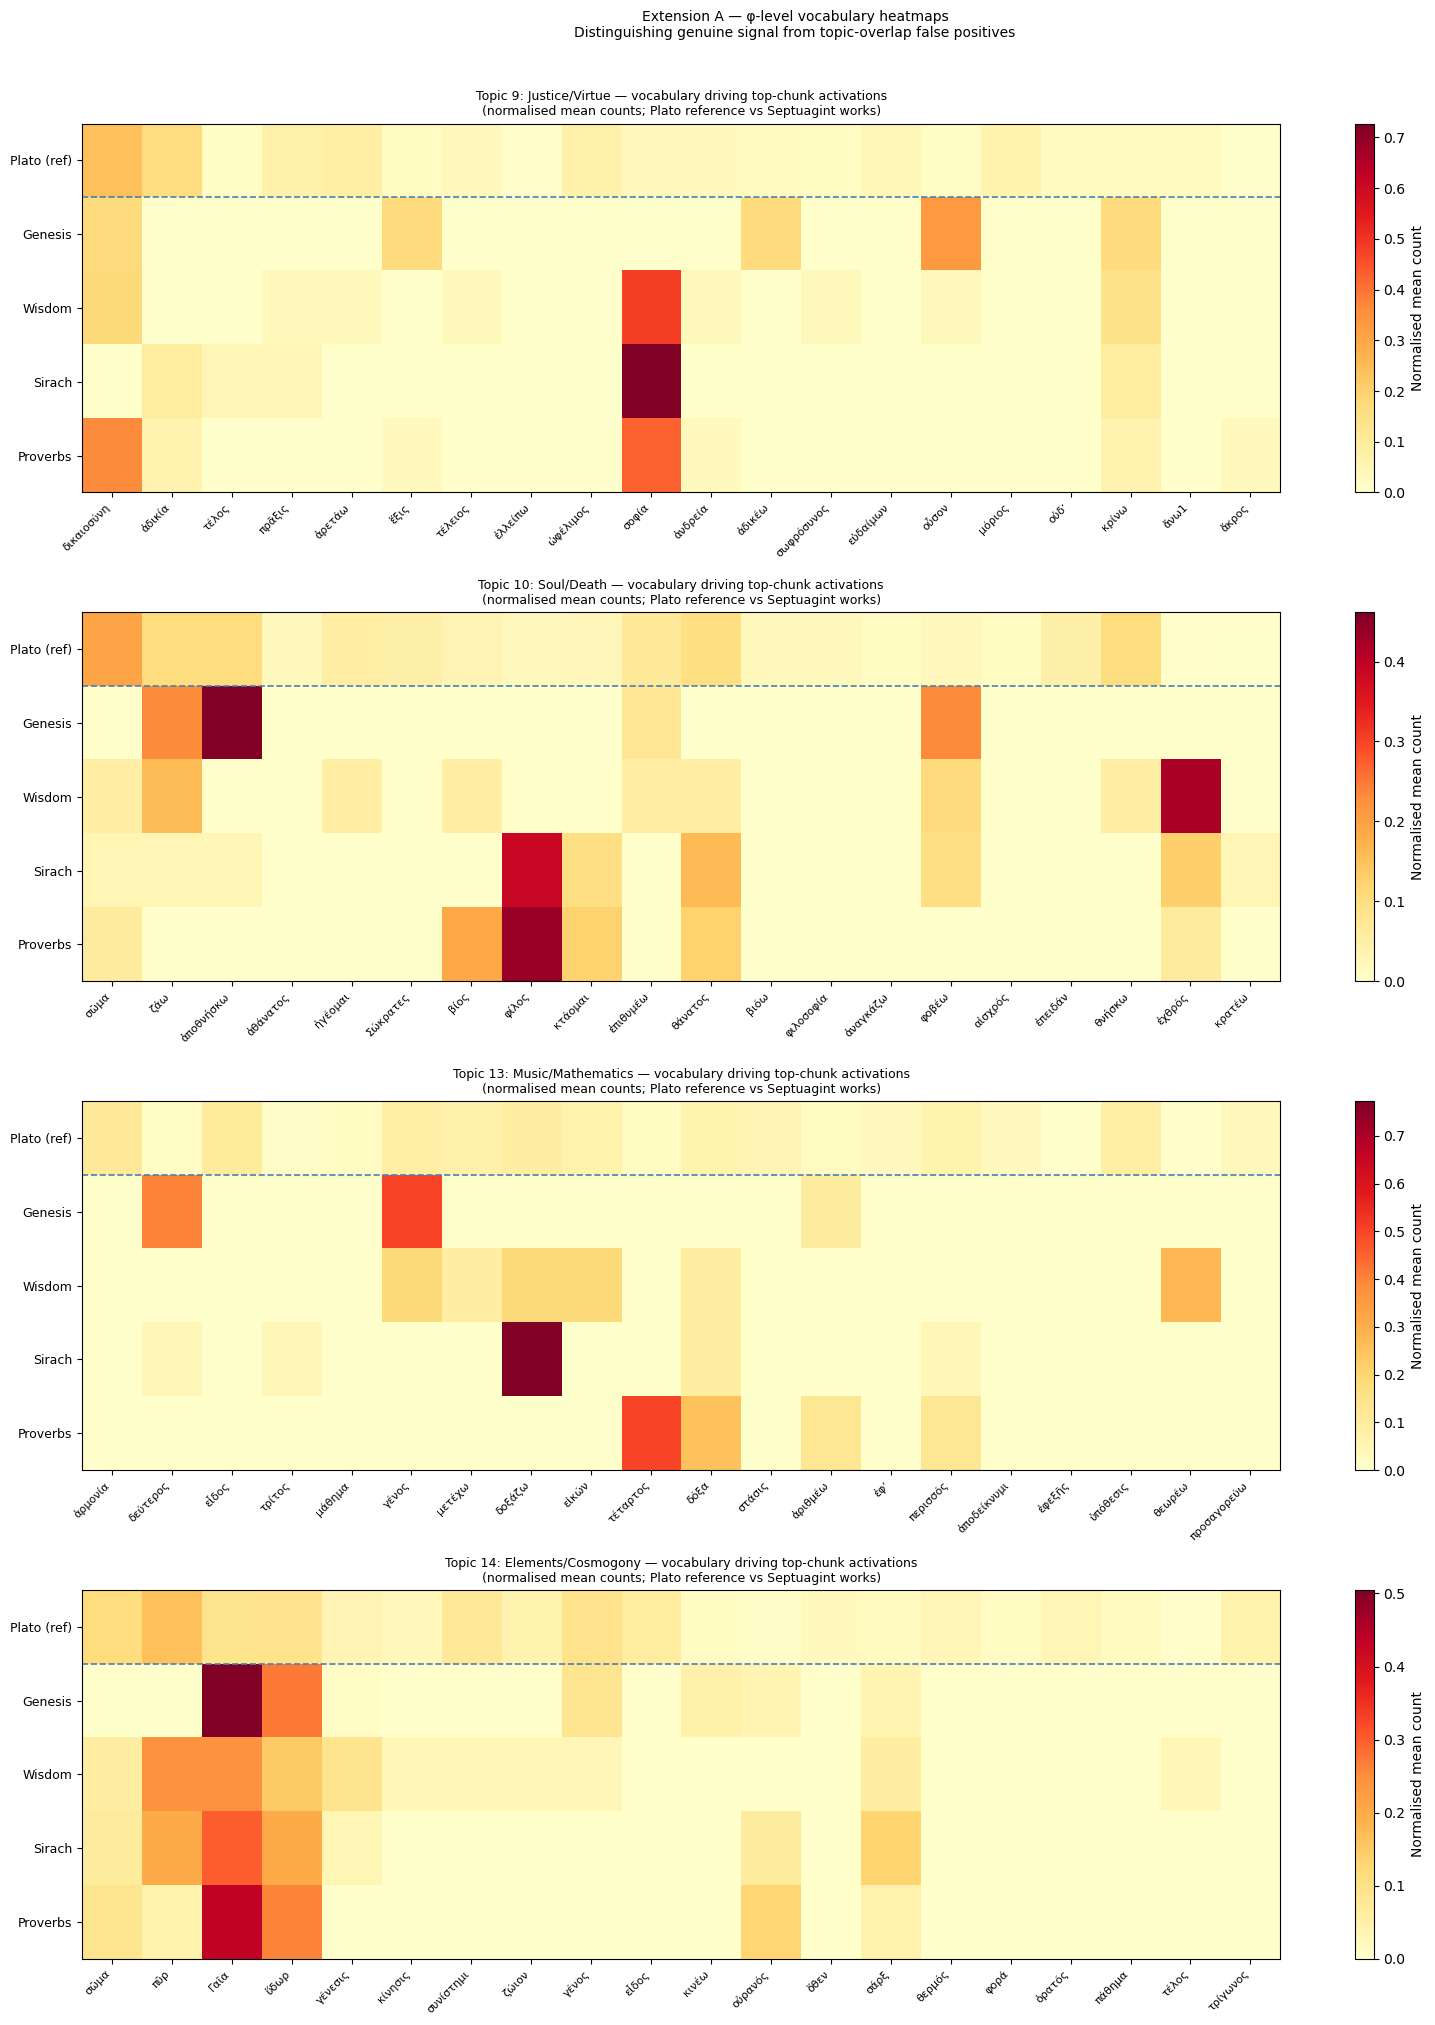

saved ext_a1


In [32]:
# A3. vocabulary heatmap — which words drive Septuagint vs Plato activations

SEP_LABELS_A = {
    'septuagint_genesis':  'Genesis',
    'septuagint_wisdom':   'Wisdom',
    'septuagint_sirach':   'Sirach',
    'septuagint_proverbs': 'Proverbs',
}

fig, axes = plt.subplots(len(FOCUS_TOPICS_A), 1, figsize=(16, 5 * len(FOCUS_TOPICS_A)))
if len(FOCUS_TOPICS_A) == 1:
    axes = [axes]

for ax, k in zip(axes, FOCUS_TOPICS_A):
    top_word_idx  = phi_b[k].argsort()[::-1][:N_WORDS]
    top_word_labs = [vocab[i] for i in top_word_idx]
    plato_ranks   = plato_theta[:, k].argsort()[::-1][:N_REF]
    plato_row     = plato_dtm[plato_ranks][:, top_word_idx].mean(axis=0)
    plato_row     = plato_row / (plato_row.sum() + 1e-10)
    rows   = [plato_row]
    labels_h = ['Plato (ref)']

    for key in SEP_WORKS:
        if key not in sep_projected_ext:
            continue
        sep_theta_k = sep_projected_ext[key]['theta'][:, k]
        sep_dtm_k   = sep_projected_ext[key]['dtm']
        sep_ranks   = sep_theta_k.argsort()[::-1][:N_SEP]
        sep_row     = sep_dtm_k[sep_ranks][:, top_word_idx].mean(axis=0)
        sep_row     = sep_row / (sep_row.sum() + 1e-10)
        rows.append(sep_row)
        labels_h.append(SEP_LABELS_A.get(key, key))

    mat_h = np.array(rows)
    im    = ax.imshow(mat_h, aspect='auto', cmap='YlOrRd', vmin=0, vmax=mat_h.max())
    ax.set_xticks(range(N_WORDS))
    ax.set_xticklabels(top_word_labs, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(labels_h)))
    ax.set_yticklabels(labels_h, fontsize=9)
    ax.set_title('Topic %d: %s \u2014 vocabulary driving top-chunk activations\n'
                 '(normalised mean counts; Plato reference vs Septuagint works)' % (
                 k, TOPIC_LABELS[k]), fontsize=9)
    ax.axhline(0.5, color='steelblue', linewidth=1.2, linestyle='--')
    plt.colorbar(im, ax=ax, label='Normalised mean count')

fig.suptitle('Extension A \u2014 \u03c6-level vocabulary heatmaps\n'
             'Distinguishing genuine signal from topic-overlap false positives',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/ext_a1_sep_vocab_heatmaps.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/ext_a1_sep_vocab_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved ext_a1')

In [33]:
# A4. Genesis T14 anatomy: cosmogony vocabulary overlap with Timaeus

k_cosm   = 14
N_DETAIL = 15

top_word_idx_c  = phi_b[k_cosm].argsort()[::-1][:N_DETAIL]
top_word_labs_c = [vocab[i] for i in top_word_idx_c]
top_phi_vals_c  = phi_b[k_cosm, top_word_idx_c]

timaeus_idx_c   = [i for i, m in enumerate(doc_meta) if work_key(m) == 'plato_timaeus']
timaeus_theta_c = theta[timaeus_idx_c]
timaeus_dtm_c   = dtms['dtm_baseline'][timaeus_idx_c]
tim_top         = timaeus_theta_c[:, k_cosm].argsort()[::-1][:20]
tim_freq        = timaeus_dtm_c[tim_top][:, top_word_idx_c].mean(axis=0)

gen_key_c   = 'septuagint_genesis'
gen_theta_c = sep_projected_ext[gen_key_c]['theta'][:, k_cosm]
gen_dtm_c   = sep_projected_ext[gen_key_c]['dtm']
gen_top_c   = gen_theta_c.argsort()[::-1][:10]
gen_freq    = gen_dtm_c[gen_top_c][:, top_word_idx_c].mean(axis=0)

plato_nontim_idx   = [i for i, m in enumerate(doc_meta)
                      if 'plato' in m['author'] and work_key(m) != 'plato_timaeus']
plato_nontim_theta = theta[plato_nontim_idx]
plato_nontim_dtm   = dtms['dtm_baseline'][plato_nontim_idx]
pnt_top            = plato_nontim_theta[:, k_cosm].argsort()[::-1][:20]
pnt_freq           = plato_nontim_dtm[pnt_top][:, top_word_idx_c].mean(axis=0)

print('T%d (%s) \u2014 Genesis / Timaeus vocabulary comparison' % (k_cosm, TOPIC_LABELS[k_cosm]))
print()
print('%-20s  %10s  %12s  %12s  %12s' % (
    'word', 'phi', 'timaeus_freq', 'genesis_freq', 'other_plato'))
print('-' * 72)
for w, phi_v, tf, gf, pf in zip(top_word_labs_c, top_phi_vals_c, tim_freq, gen_freq, pnt_freq):
    marker = ' <-- shared' if tf > 0.1 and gf > 0.1 else ''
    print('%-20s  %10.4f  %12.4f  %12.4f  %12.4f%s' % (w, phi_v, tf, gf, pf, marker))

tim_norm  = tim_freq / (tim_freq.sum() + 1e-10)
gen_norm  = gen_freq / (gen_freq.sum() + 1e-10)
pnt_norm  = pnt_freq / (pnt_freq.sum() + 1e-10)
c_tim_gen = cosine(tim_norm, gen_norm)
c_pnt_gen = cosine(pnt_norm, gen_norm)
print('\ncosine(timaeus, genesis)     on T14 vocabulary: %.4f' % c_tim_gen)
print('cosine(other_plato, genesis) on T14 vocabulary: %.4f' % c_pnt_gen)
print('\nif c_tim_gen >> c_pnt_gen: genesis T14 activation is timaeus-specific.')
print('if c_tim_gen < c_pnt_gen:  genesis T14 activation reflects general platonic vocabulary.')

T14 (Elements/Cosmogony) — Genesis / Timaeus vocabulary comparison

word                         phi  timaeus_freq  genesis_freq   other_plato
------------------------------------------------------------------------
σῶμα                      0.0629        2.1000        0.1000        1.8000
πῦρ                       0.0543        3.3500        0.1000        0.4000
Γαῖα                      0.0516        2.0500       10.6000        1.6000 <-- shared
ὕδωρ                      0.0389        2.0000        3.4000        0.5000 <-- shared
γένεσις                   0.0285        0.9000        0.1000        0.4500
κίνησις                   0.0243        0.5000        0.0000        0.3500
συνίστημι                 0.0215        1.6500        0.0000        0.1000
ζώιον                     0.0205        0.8500        0.0000        0.4500
γένος                     0.0174        2.1500        1.6000        0.4500 <-- shared
εἶδος                     0.0163        1.1500        0.0000        0.7500
κ

In [34]:
# A5. Wisdom T10 anatomy: testing Platonic soul-immortality penetration

k_soul   = 10
N_DETAIL = 15

top_word_idx_s  = phi_b[k_soul].argsort()[::-1][:N_DETAIL]
top_word_labs_s = [vocab[i] for i in top_word_idx_s]
top_phi_vals_s  = phi_b[k_soul, top_word_idx_s]

phaedo_idx_s   = [i for i, m in enumerate(doc_meta) if work_key(m) == 'plato_phaedo']
phaedo_theta_s = theta[phaedo_idx_s]
phaedo_dtm_s   = dtms['dtm_baseline'][phaedo_idx_s]
phd_top        = phaedo_theta_s[:, k_soul].argsort()[::-1][:20]
phd_freq       = phaedo_dtm_s[phd_top][:, top_word_idx_s].mean(axis=0)

wis_key_s   = 'septuagint_wisdom'
wis_theta_s = sep_projected_ext[wis_key_s]['theta'][:, k_soul]
wis_dtm_s   = sep_projected_ext[wis_key_s]['dtm']
wis_top_s   = wis_theta_s.argsort()[::-1][:10]
wis_freq    = wis_dtm_s[wis_top_s][:, top_word_idx_s].mean(axis=0)

print('T%d (%s) \u2014 Wisdom vs Phaedo vocabulary comparison' % (k_soul, TOPIC_LABELS[k_soul]))
print()
print('%-20s  %10s  %12s  %12s' % ('word', 'phi', 'phaedo_freq', 'wisdom_freq'))
print('-' * 58)
for w, phi_v, pf, wf in zip(top_word_labs_s, top_phi_vals_s, phd_freq, wis_freq):
    marker = ' <-- shared' if pf > 0.05 and wf > 0.05 else ''
    print('%-20s  %10.4f  %12.4f  %12.4f%s' % (w, phi_v, pf, wf, marker))

phd_norm_s  = phd_freq / (phd_freq.sum() + 1e-10)
wis_norm_s  = wis_freq / (wis_freq.sum() + 1e-10)
c_phd_wis   = cosine(phd_norm_s, wis_norm_s)
print('\ncosine(phaedo, wisdom) on T10 vocabulary: %.4f' % c_phd_wis)

T10 (Soul/Death) — Wisdom vs Phaedo vocabulary comparison

word                         phi   phaedo_freq   wisdom_freq
----------------------------------------------------------
σῶμα                      0.0274        2.6500        0.4000 <-- shared
ζάω                       0.0130        1.4000        0.4000 <-- shared
ἀποθνήσκω                 0.0104        1.4000        0.0000
ἀθάνατος                  0.0091        1.0500        0.1000 <-- shared
ἡγέομαι                   0.0091        0.4000        0.3000 <-- shared
Σώκρατες                  0.0090        0.9500        0.0000
βίος                      0.0090        0.3500        0.5000 <-- shared
φίλος                     0.0081        0.2500        0.1000 <-- shared
κτάομαι                   0.0078        0.2500        0.0000
ἐπιθυμέω                  0.0073        0.3500        0.1000 <-- shared
θάνατος                   0.0073        0.8000        0.4000 <-- shared
βιόω                      0.0071        0.1000        0.0000
φ

In [35]:
# A6. morphological entropy of topic-driving vocabulary
# FIX: gen_top_k and wis_top_k are recomputed per-topic inside the loop
# (the original notebook erroneously reused gen_top/wis_top from cells A4/A5
# which were scoped to k_cosm=14 and k_soul=10 respectively).

def mean_entropy_of_words(word_list):
    h_vals = []
    for w in word_list:
        dist = lm.lemma_dist(w)
        h    = -sum(p * math.log2(p) for p in dist.values() if p > 0)
        h_vals.append(h)
    return np.mean(h_vals) if h_vals else 0.0

print('morphological entropy of topic-driving vocabulary')
print('%-35s  %12s  %12s  %12s  %12s' % (
    'topic', 'phi_top20_H', 'plato_H', 'genesis_H', 'wisdom_H'))
print('-' * 85)

for k in FOCUS_TOPICS_A:
    top_idx   = phi_b[k].argsort()[::-1][:20]
    top_words = [vocab[i] for i in top_idx]

    plato_ranks_k  = plato_theta[:, k].argsort()[::-1][:20]
    plato_counts_k = plato_dtm[plato_ranks_k][:, top_idx].mean(axis=0)
    plato_active   = [top_words[i] for i in range(20) if plato_counts_k[i] > 0.1]

    # recompute gen_top_k and wis_top_k per topic (bug fix from original notebook)
    gen_top_k  = sep_projected_ext['septuagint_genesis']['theta'][:, k].argsort()[::-1][:10]
    gen_counts = sep_projected_ext['septuagint_genesis']['dtm'][gen_top_k][:, top_idx].mean(axis=0)
    gen_active = [top_words[i] for i in range(20) if gen_counts[i] > 0.1]

    wis_top_k  = sep_projected_ext['septuagint_wisdom']['theta'][:, k].argsort()[::-1][:10]
    wis_counts = sep_projected_ext['septuagint_wisdom']['dtm'][wis_top_k][:, top_idx].mean(axis=0)
    wis_active = [top_words[i] for i in range(20) if wis_counts[i] > 0.1]

    h_phi   = mean_entropy_of_words(top_words)
    h_plato = mean_entropy_of_words(plato_active) if plato_active else 0.0
    h_gen   = mean_entropy_of_words(gen_active)   if gen_active   else 0.0
    h_wis   = mean_entropy_of_words(wis_active)   if wis_active   else 0.0

    print('T%d: %-30s  %12.4f  %12.4f  %12.4f  %12.4f' % (
        k, TOPIC_LABELS[k], h_phi, h_plato, h_gen, h_wis))

morphological entropy of topic-driving vocabulary
topic                                 phi_top20_H       plato_H     genesis_H      wisdom_H
-------------------------------------------------------------------------------------
T9: Justice/Virtue                        0.1520        0.1689        0.3333        0.2500
T10: Soul/Death                            0.0703        0.0781        0.0000        0.0000
T13: Music/Mathematics                     0.0825        0.0382        0.0000        0.0000
T14: Elements/Cosmogony                    0.2135        0.2247        0.0000        0.1111


### Extension E: Topic Coherence Under Morphological Uncertainty

In [36]:
# E1. NPMI coherence for baseline and 10 sampled phi matrices

N_COH  = 10
X_coh  = dtms['dtm_baseline']
df_coh = (X_coh > 0).astype(np.float32)
p_word = df_coh.mean(axis=0)

def npmi_coherence(phi_row, top_n=N_COH):
    top_idx = phi_row.argsort()[::-1][:top_n]
    scores  = []
    for i in range(len(top_idx)):
        for j in range(i + 1, len(top_idx)):
            wi, wj = top_idx[i], top_idx[j]
            p_i  = p_word[wi]
            p_j  = p_word[wj]
            p_ij = (df_coh[:, wi] * df_coh[:, wj]).mean()
            if p_ij < 1e-10 or p_i < 1e-10 or p_j < 1e-10:
                continue
            pmi  = math.log(p_ij / (p_i * p_j))
            npmi = pmi / (-math.log(p_ij))
            scores.append(npmi)
    return np.mean(scores) if scores else 0.0

print('computing coherence for baseline phi...')
coh_baseline = np.array([npmi_coherence(phi_b[k]) for k in range(K)])

N_COHERENCE_SAMPLES = 10
print('computing coherence for %d sampled phi matrices...' % N_COHERENCE_SAMPLES)

coh_samples = np.zeros((N_COHERENCE_SAMPLES, K))
for s in range(N_COHERENCE_SAMPLES):
    X_s   = dtms['dtm_samples'][s]
    lda_s = LatentDirichletAllocation(
        n_components=K, max_iter=N_ITER,
        learning_method='online', batch_size=128,
        learning_offset=10.0, learning_decay=0.7,
        random_state=SEED + s, n_jobs=1,
    )
    lda_s.fit(X_s)
    phi_s_row = lda_s.components_ / lda_s.components_.sum(axis=1, keepdims=True)
    for k in range(K):
        coh_samples[s, k] = npmi_coherence(phi_s_row[k])
    print('  sample %2d/%d done' % (s+1, N_COHERENCE_SAMPLES), end='\r')

coh_mean = coh_samples.mean(axis=0)
coh_std  = coh_samples.std(axis=0)
print('\ncoherence computation complete')

computing coherence for baseline phi...
computing coherence for 10 sampled phi matrices...
  sample 10/10 done
coherence computation complete


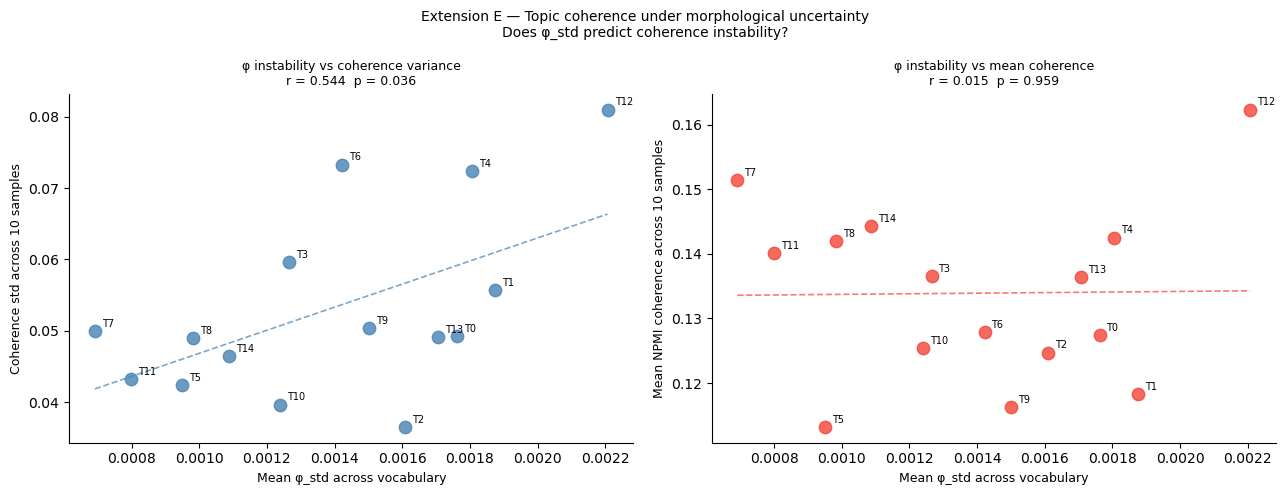


summary table (sorted by phi_std descending)
topic   label                              phi_std    coh_mean     coh_std
----------------------------------------------------------------------
T12     Form/Beauty                        0.00221      0.1624      0.0810
T1      Cosmology/Vision                   0.00187      0.1183      0.0556
T4      Dialectic/Falsehood                0.00181      0.1425      0.0724
T0      Mimesis/Poetics                    0.00176      0.1274      0.0493
T13     Music/Mathematics                  0.00171      0.1364      0.0491
T2      Forms/Knowledge                    0.00161      0.1247      0.0365
T9      Justice/Virtue                     0.00150      0.1162      0.0503
T6      Desire/Eros                        0.00142      0.1279      0.0733
T3      Division/Classification            0.00127      0.1365      0.0596
T10     Soul/Death                         0.00124      0.1254      0.0396
T14     Elements/Cosmogony                 0.00109      0.

In [37]:
# E2. correlate phi_std with coherence variance

phi_std_per_topic = phi_std.mean(axis=1)
r_std_coh,  p_std_coh  = pearsonr(phi_std_per_topic, coh_std)
r_std_mean, p_std_mean = pearsonr(phi_std_per_topic, coh_mean)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(phi_std_per_topic, coh_std, s=80, color='steelblue', alpha=0.8, zorder=3)
for k in range(K):
    ax1.annotate('T%d' % k, (phi_std_per_topic[k], coh_std[k]),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)
m1, b1 = np.polyfit(phi_std_per_topic, coh_std, 1)
xs = np.linspace(phi_std_per_topic.min(), phi_std_per_topic.max(), 100)
ax1.plot(xs, m1*xs + b1, color='steelblue', linewidth=1.2, linestyle='--', alpha=0.7)
ax1.set_xlabel('Mean \u03c6_std across vocabulary', fontsize=9)
ax1.set_ylabel('Coherence std across %d samples' % N_COHERENCE_SAMPLES, fontsize=9)
ax1.set_title('\u03c6 instability vs coherence variance\nr = %.3f  p = %.3f' % (
    r_std_coh, p_std_coh), fontsize=9)
ax1.spines[['top','right']].set_visible(False)

ax2.scatter(phi_std_per_topic, coh_mean, s=80, color='#F44336', alpha=0.8, zorder=3)
for k in range(K):
    ax2.annotate('T%d' % k, (phi_std_per_topic[k], coh_mean[k]),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)
m2, b2 = np.polyfit(phi_std_per_topic, coh_mean, 1)
ax2.plot(xs, m2*xs + b2, color='#F44336', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.set_xlabel('Mean \u03c6_std across vocabulary', fontsize=9)
ax2.set_ylabel('Mean NPMI coherence across %d samples' % N_COHERENCE_SAMPLES, fontsize=9)
ax2.set_title('\u03c6 instability vs mean coherence\nr = %.3f  p = %.3f' % (
    r_std_mean, p_std_mean), fontsize=9)
ax2.spines[['top','right']].set_visible(False)

fig.suptitle('Extension E \u2014 Topic coherence under morphological uncertainty\n'
             'Does \u03c6_std predict coherence instability?', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/ext_e1_coherence_phi_std.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/ext_e1_coherence_phi_std.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nsummary table (sorted by phi_std descending)')
print('%-6s  %-30s  %10s  %10s  %10s' % ('topic', 'label', 'phi_std', 'coh_mean', 'coh_std'))
print('-' * 70)
order_e = phi_std_per_topic.argsort()[::-1]
for k in order_e:
    print('T%-5d  %-30s  %10.5f  %10.4f  %10.4f' % (
        k, TOPIC_LABELS[k], phi_std_per_topic[k], coh_mean[k], coh_std[k]))
print('saved ext_e1')

### Extension F: Post-hoc Covariate Regression

In [38]:
# F1. build document-level metadata matrix
# period classification follows Brandwood (1992) consensus;
# Timaeus assigned to late Plato (period=2).

PERIOD_MAP = {
    'plato_apology':                0,   # early
    'plato_meno':                   0,
    'plato_ion':                    0,
    'plato_republic':               1,   # middle
    'plato_symposium':              1,
    'plato_phaedrus':               1,
    'plato_phaedo':                 1,
    'plato_sophist':                2,   # late
    'plato_timaeus':                2,
    'aristotle_nicomachean_ethics': 3,
    'aristotle_metaphysics':        3,
    'aristotle_poetics':            3,
}

GENRE_MAP = {
    'plato_apology':                0,   # dialogue
    'plato_meno':                   0,
    'plato_ion':                    0,
    'plato_republic':               0,
    'plato_symposium':              0,
    'plato_phaedrus':               0,
    'plato_phaedo':                 0,
    'plato_sophist':                0,
    'plato_timaeus':                0,   # monological dialogue
    'aristotle_nicomachean_ethics': 1,   # treatise
    'aristotle_metaphysics':        1,
    'aristotle_poetics':            2,   # drama criticism
}

author_vec = np.array([0 if 'plato' in m['author'] else 1 for m in doc_meta])
period_vec = np.array([PERIOD_MAP.get(work_key(m), -1) for m in doc_meta])
genre_vec  = np.array([GENRE_MAP.get(work_key(m),  -1) for m in doc_meta])

valid_mask   = (period_vec >= 0) & (genre_vec >= 0)
theta_valid  = theta[valid_mask]
author_valid = author_vec[valid_mask]
period_valid = period_vec[valid_mask]
genre_valid  = genre_vec[valid_mask]

print('valid chunks: %d / %d' % (valid_mask.sum(), len(doc_meta)))
print('plato=%d  aristotle=%d' % ((author_valid==0).sum(), (author_valid==1).sum()))

valid chunks: 1133 / 1133
plato=668  aristotle=465


In [39]:
# F2. regression: topic prevalence ~ author + period + genre

ohe_period = OneHotEncoder(sparse_output=False, drop='first')
ohe_genre  = OneHotEncoder(sparse_output=False, drop='first')
period_ohe = ohe_period.fit_transform(period_valid.reshape(-1, 1))
genre_ohe  = ohe_genre.fit_transform(genre_valid.reshape(-1, 1))

X_meta = np.hstack([author_valid.reshape(-1, 1), period_ohe, genre_ohe])

period_levels  = ['period=middle', 'period=late', 'period=aristotle']
genre_levels   = ['genre=treatise', 'genre=drama']
feature_labels = ['author=aristotle'] + period_levels + genre_levels

reg_results = {}
for k in range(K):
    y      = theta_valid[:, k]
    reg    = LinearRegression().fit(X_meta, y)
    y_pred = reg.predict(X_meta)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    reg_results[k] = {'r2': r2, 'coefs': dict(zip(feature_labels, reg.coef_))}

print('covariate regression: topic prevalence ~ author + period + genre')
print('(post-hoc OLS; simplified STM in spirit of Roberts et al. 2014)')
print()
print('%-6s  %-28s  %6s  strongest predictor' % ('topic', 'label', 'R²'))
print('-' * 70)
order_f = sorted(range(K), key=lambda k: -reg_results[k]['r2'])
for k in order_f:
    res    = reg_results[k]
    best_f = max(res['coefs'], key=lambda f: abs(res['coefs'][f]))
    print('T%-5d  %-28s  %6.3f  %s (coef=%.4f)' % (
        k, TOPIC_LABELS[k], res['r2'], best_f, res['coefs'][best_f]))

covariate regression: topic prevalence ~ author + period + genre
(post-hoc OLS; simplified STM in spirit of Roberts et al. 2014)

topic   label                             R²  strongest predictor
----------------------------------------------------------------------
T7      Metaphysics/Ontology           0.364  genre=treatise (coef=0.1607)
T0      Mimesis/Poetics                0.333  genre=drama (coef=0.1656)
T11     Teaching/Inquiry               0.302  period=late (coef=-0.2537)
T10     Soul/Death                     0.297  period=middle (coef=0.0699)
T14     Elements/Cosmogony             0.221  period=late (coef=0.2163)
T6      Desire/Eros                    0.154  period=late (coef=-0.0813)
T5      Pleasure/Friendship            0.095  genre=treatise (coef=0.0958)
T1      Cosmology/Vision               0.090  period=late (coef=0.0641)
T13     Music/Mathematics              0.042  period=late (coef=0.0888)
T3      Division/Classification        0.040  period=late (coef=0.0365)
T2 

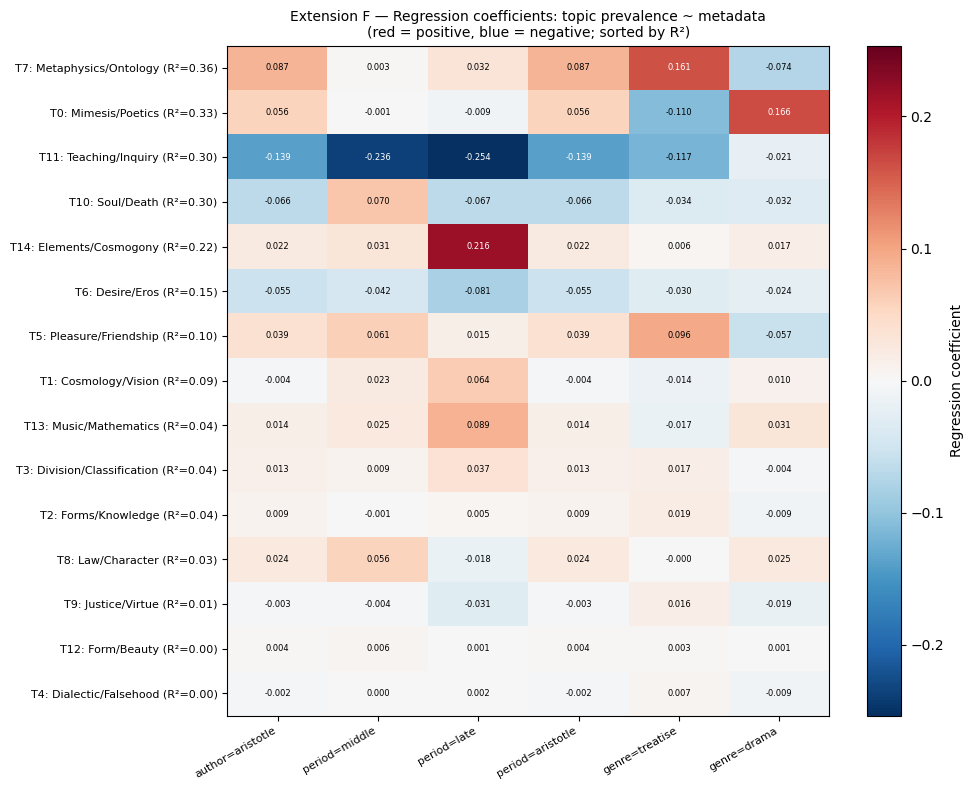

saved ext_f1


In [40]:
# F3. coefficient heatmap

coef_mat  = np.array([[reg_results[k]['coefs'][f] for f in feature_labels]
                      for k in order_f])
ylabels_f = ['T%d: %s (R\u00b2=%.2f)' % (k, TOPIC_LABELS[k], reg_results[k]['r2'])
             for k in order_f]
vmax = np.abs(coef_mat).max()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coef_mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(feature_labels)))
ax.set_xticklabels(feature_labels, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(ylabels_f)))
ax.set_yticklabels(ylabels_f, fontsize=8)
ax.set_title('Extension F \u2014 Regression coefficients: topic prevalence ~ metadata\n'
             '(red = positive, blue = negative; sorted by R\u00b2)', fontsize=10)
plt.colorbar(im, ax=ax, label='Regression coefficient')

for i in range(len(order_f)):
    for j in range(len(feature_labels)):
        ax.text(j, i, '%.3f' % coef_mat[i, j],
                ha='center', va='center', fontsize=6,
                color='white' if abs(coef_mat[i, j]) > vmax * 0.5 else 'black')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '/ext_f1_covariate_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR + '/ext_f1_covariate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved ext_f1')

In [41]:
# F4. within-Plato periodization regression
# does period (early/middle/late) predict topic prevalence within Plato alone?
# timaeus is late (period=2); its cosmological topics should show positive coef:late.

plato_mask   = (author_valid == 0)
theta_plato  = theta_valid[plato_mask]
period_plato = period_valid[plato_mask]

ohe_p2 = OneHotEncoder(sparse_output=False, drop='first')
X_p    = ohe_p2.fit_transform(period_plato.reshape(-1, 1))

print('within-plato: topic prevalence ~ period (early = reference category)')
print()
print('%-6s  %-28s  %6s  %12s  %12s' % (
    'topic', 'label', 'R²', 'coef:middle', 'coef:late'))
print('-' * 70)

plato_reg_results = {}
for k in range(K):
    y      = theta_plato[:, k]
    reg    = LinearRegression().fit(X_p, y)
    y_pred = reg.predict(X_p)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    plato_reg_results[k] = {'r2': r2, 'coefs': reg.coef_}

p_order = sorted(range(K), key=lambda k: -plato_reg_results[k]['r2'])
for k in p_order[:10]:
    res = plato_reg_results[k]
    print('T%-5d  %-28s  %6.3f  %12.4f  %12.4f' % (
        k, TOPIC_LABELS[k], res['r2'], res['coefs'][0], res['coefs'][1]))

within-plato: topic prevalence ~ period (early = reference category)

topic   label                             R²   coef:middle     coef:late
----------------------------------------------------------------------
T14     Elements/Cosmogony             0.322        0.0306        0.2163
T11     Teaching/Inquiry               0.121       -0.2362       -0.2537
T3      Division/Classification        0.067        0.0092        0.0365
T10     Soul/Death                     0.064        0.0699       -0.0673
T8      Law/Character                  0.056        0.0563       -0.0176
T13     Music/Mathematics              0.047        0.0249        0.0888
T5      Pleasure/Friendship            0.043        0.0608        0.0146
T7      Metaphysics/Ontology           0.037        0.0027        0.0318
T1      Cosmology/Vision               0.029        0.0227        0.0641
T6      Desire/Eros                    0.021       -0.0418       -0.0813
